***МОДУЛЬНАЯ РАБОТА №1***

В рамках данного исследования в качестве эмпирической базы были использованы данные международной организации OECD, представленные в рамках проекта Better Life Index.
Данный индекс отражает уровень благополучия населения в различных странах мира и включает в себя широкий набор социально-экономических показателей, характеризующих качество жизни.
В используемом датасете представлены пространственные данные по странам (более 40 наблюдений). Каждое наблюдение соответствует отдельной стране, а признаки представляют собой количественные показатели, отражающие различные аспекты благополучия.


***Цель и задачи исследования***
Целью работы является проведение статистического анализа "уровня счастья" на основе пространственных данных по странам.



Был загружен файл "better-life-index-2024.csv". Прочитаем содержимое файла и выведем на экран

In [ ]:
import pandas as pd

df = pd.read_csv('better-life-index-2024.csv')

df.head()

,Country,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,...,Water quality,Stakeholder engagement for developing regulations,Voter turnout,Life expectancy,Self-reported health,Feeling safe walking alone at night,Homicide rate,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
0,Australia,66589,NaN,19.4,NaN,37433.0,528768.0,3.1,73,1.0,...,92,2.7,92,83.0,85,67,0.9,12.5,14.36,7.1
1,Austria,59225,0.8,20.8,1.6,37001.0,309637.0,2.3,72,1.3,...,92,1.3,76,82.0,71,86,0.5,5.3,14.51,7.2
2,Belgium,55536,0.7,20.0,2.1,34884.0,447607.0,2.4,65,2.3,...,79,2.0,88,82.1,74,56,1.1,4.3,15.52,6.8
3,Canada,54866,0.2,22.9,2.6,34421.0,478240.0,3.8,70,0.5,...,90,2.9,68,82.1,89,78,1.2,3.3,14.57,7.0
4,Chile,16616,9.4,18.4,1.9,NaN,135787.0,7.0,56,NaN,...,62,1.3,47,80.6,60,41,2.4,7.7,NaN,6.2


Из полученной таблицы видно, что каждая строка соответствует отдельной стране (например, Australia, Austria, Belgium, Canada, Chile), а столбцы представляют собой различные количественные показатели, характеризующие уровень жизни.
Например:
GDP per capita (USD) — валовой внутренний продукт на душу населения;
Dwellings without basic facilities — доля жилья без базовых удобств;
Housing expenditure — расходы на жильё;
Rooms per person — количество комнат на человека;
Household net adjusted disposable income — располагаемый доход домохозяйств;
Household net wealth — чистое богатство домохозяйств;
Labour market insecurity — нестабильность на рынке труда;
Employment rate — уровень занятости;
Long-term unemployment rate — уровень долгосрочной безработицы;
Water quality — качество воды;
Voter turnout — явка на выборах;
Life expectancy — ожидаемая продолжительность жизни;
Self-reported health — субъективная оценка здоровья;
Homicide rate — уровень преступности;
Employees working very long hours — доля людей, работающих сверхурочно;
Time devoted to leisure and personal care — время на отдых;
***Life satisfaction — удовлетворённость жизнью*** - ключевой показатель, который мы рассмотрим в исследовании.

В дальнейшей работе мы попытаемся понять, какие именно факоры оказывают наибольшее влияние на этот показатель и будем искать взаимосвязи этой характеристики и других параметров.

***ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ***


Целью предварительного анализа является изучение структуры и статистических характеристик показателя Life satisfaction (удовлетворенность жизнью) для разных стран.
Данный показатель отражает субъективную оценку населением качества жизни и измеряется по шкале **от 0 до 10**.


В работе используется **датасет Better Life Index 2024**, содержащий социально-экономические показатели стран.

Перед проведением анализа были выдвинуты **следующие гипотезы**:

-Уровень удовлетворённости жизнью различается между странами, что связано с различиями в уровне экономического развития, доходов населения и социальных условий.

-Распределение показателя удовлетворённости жизнью может иметь асимметрию, так как в экономически развитых странах значения обычно выше.

-В выборке могут присутствовать выбросы, связанные с очень высокими или очень низкими значениями показателя.

-Средний уровень удовлетворённости жизнью в странах мира находится в диапазоне 6–8 баллов, что соответствует результатам международных исследований качества жизни.

Сейчас я импортировала библиотеки и очистила данные от пробелов для дальнейщего анализа:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("better-life-index-2024.csv")

df.columns = df.columns.str.strip()

life = df["Life satisfaction"]

life.head()

,Life satisfaction
0,7.1
1,7.2
2,6.8
3,7.0
4,6.2


***Графическое представление данных***

Итак, для первичного анализа распределения случайной величины была построена точечная диаграмма (то есть **Dotplot**). С помощью точечной диаграммы мы сможем выявить диапазон изменения показателя, плотность распределения значений, а также наличие потенциальных выбросов.

Точечная диаграмма показывает, что значения Life satisfaction сосредоточены в сравнительно узком интервале. Это означает, что у большинства стран уровень субъективного благополучия находится недалеко от среднего значения, а крайние значения встречаются редко. С экономической точки зрения это говорит о том, что различия между странами есть, но они не являются чрезмерными.

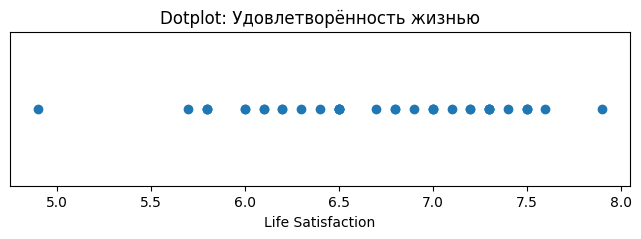

In [ ]:
plt.figure(figsize=(8,2))
plt.plot(life, np.zeros_like(life), 'o')
plt.yticks([])
plt.title("Dotplot: Удовлетворённость жизнью")
plt.xlabel("Life Satisfaction")
plt.show()

***Листовая диаграмма***

Затем построила листовую диаграмму или же другмим словами stem-and-leaf plot, чтобы изучить более детально  распределение данных, но при этом сохраняя исходные значения наблюдений. Как известно, листовая диаграмма поможет оценить структуру распределения, выявить группировки значений
и даже обнаружить возможные выбросы.

Проанализировав диаграмму можно утверждать, что основная масса наблюдений приходится на диапазон примерно от 6 до 7,5. Это указывает на достаточно **плотную концентрацию** значений в средней части распределения.

In [ ]:
import numpy as np

life_sorted = np.sort(life)

stems = np.floor(life_sorted).astype(int)
leaves = ((life_sorted - stems) * 10).astype(int)

for s, l in zip(stems, leaves):
    print(f"{s} | {l}")

4 | 9
5 | 7
5 | 7
5 | 7
5 | 7
6 | 0
6 | 0
6 | 0
6 | 0
6 | 2
6 | 2
6 | 2
6 | 4
6 | 5
6 | 5
6 | 5
6 | 5
6 | 5
6 | 7
6 | 7
6 | 7
6 | 9
7 | 0
7 | 0
7 | 0
7 | 0
7 | 2
7 | 2
7 | 2
7 | 2
7 | 2
7 | 2
7 | 4
7 | 5
7 | 5
7 | 5
7 | 5
7 | 9


***Диагностика выбросов***

Для выявления возможных выбросов была построена ящичковая диаграмма (boxplot).

На самом деле, ящичковая диаграмма показывает отсутствие ярко выраженных экстремальных наблюдений, то есть распределение не содержит аномально низких или высоких значений, резко отличающихся от остальных стран.

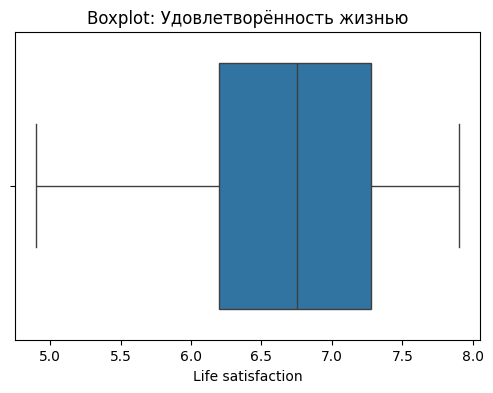

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=life)
plt.title("Boxplot: Удовлетворённость жизнью")
plt.show()

***Характеристики положения***

Обратимся к характеристикам положения и рассчитаем среднее значение, медиану и моду.

Пройдемся по полученным данным. Среднее значение удовлетворённости жизнью составило 6.69, медиана — 6.75, мода — 6.5. Близость среднего и медианы показывает, что распределение близко к симметричному и не имеет сильного перекоса. Это значит, что типичный уровень удовлетворённости жизнью в выборке стран находится примерно на уровне 6.5–6.8 балла.

Если рассмотреть данный факт с экономической точки зрения, то можно интерпретировать так: большинство исследуемых стран демонстрируют **довольно близкие значения субъективного благополучия**, а не резкое расслоение на “очень благополучные” и “очень неблагополучные” группы. Мода 6.5 означает, что примерно такое значение встречается чаще всего в нашей выборке.

In [ ]:
mean = life.mean()
median = life.median()
mode = life.mode()[0]

print("Среднее значение:", mean)
print("Медиана:", median)
print("Мода:", mode)

Среднее значение: 6.686842105263159
Медиана: 6.75
Мода: 6.5


***Характеристики разброса***

После получения значения размаха вариации, дисперсии, стандартного отклонения и коэффициента вариации можно сделать следующие выводы:


Итак, размах вариации равен 3.0, то есть значения удовлетворённости жизнью в выборке отличаются максимум на 3 балла. Это показывает, что диапазон изменений не слишком широкий. Дисперсия составила 0.4433, а стандартное отклонение — 0.6658, что подтверждает умеренный разброс значений относительно среднего уровня.

Коэффициент вариации равен 9.96%, то есть изменчивость показателя невысокая. Обычно это означает, что данные достаточно однородны, и страны в выборке не слишком сильно отличаются друг от друга по уровню удовлетворённости жизнью. С экономической точки зрения можно сказать, что субъективное благополучие распределено довольно равномерно и не демонстрирует чрезмерной нестабильности.

In [ ]:
data_range = life.max() - life.min()
variance = life.var()
std_dev = life.std()
cv = (std_dev / mean) * 100

print("Размах вариации:", data_range)
print("Дисперсия:", variance)
print("Стандартное отклонение:", std_dev)
print("Коэффициент вариации:", cv)

Размах вариации: 3.0
Дисперсия: 0.443335704125178
Стандартное отклонение: 0.6658345921662361
Коэффициент вариации: 9.957384691978342


***Квартили и децили***

Для оценки ранговых характеристик случайной величины были рассчитаны квартили и децили. В качестве исходных данных использовался показатель Life satisfaction. Функция quantile() позволила мне определить значения, ниже которых находится заданная доля наблюдений. Квартили были найдены для уровней 25%, 50% и 75%, а децили — для уровней от 10% до 90% с шагом 10%. Это позволяет оценить, как распределены значения показателя и в каком диапазоне сосредоточена основная часть стран


Переходя к полученным данным, стоит отметить прежде всего полученные значения: первый квартиль равен 6.20, медиана — 6.75, третий квартиль — 7.275. Это означает, что 25% стран имеют уровень удовлетворённости жизнью не выше 6.2, а 75% — не выше 7.275. Следовательно, основная часть наблюдений сосредоточена в достаточно узком интервале

По децилям видно, что 10% стран имеют значение не выше 5.8, а 90% — не выше 7.5. Это подтверждает, что даже между нижней и верхней частями распределения разрыв не является критическим. Фактически, можно трактовать как наличие относительно устойчивого уровня субъективного благополучия в большинстве стран выборки

In [ ]:
quartiles = life.quantile([0.25,0.5,0.75])
deciles = life.quantile(np.arange(0.1,1,0.1))

print("Квартили")
print(quartiles)

print("\nДецили")
print(deciles)

Квартили
0.25    6.200
0.50    6.750
0.75    7.275
Name: Life satisfaction, dtype: float64

Децили
0.1    5.80
0.2    6.10
0.3    6.31
0.4    6.50
0.5    6.75
0.6    7.00
0.7    7.19
0.8    7.30
0.9    7.50
Name: Life satisfaction, dtype: float64


***Межквартильный размах (IQR)***

Переходя к Q1, Q2, IQR стоит отметить то, как я их находила: для оценки разброса центральной части распределения мною были рассчитаны первый и третий квартили, а также межквартильный размах. Первый квартиль показывает нижнюю границу примерно 25% наблюдений, а третий квартиль — нижнюю границу 75% наблюдений. Разность между ними, то есть IQR, отражает разброс средних 50% значений и позволяет оценить устойчивость распределения к выбросам, что и являлось моей целью изучения

Итак, межквартильный размах равен 1.075. Здесь я хочу отметить, что он показывает разброс центральных 50% наблюдений и считается более устойчивой мерой, чем обычный размах. Небольшое значение IQR подтверждает, что основная масса стран имеет близкие показатели удовлетворённости жизнью.

Это означает, что “средняя зона” распределения довольно компактна, а значит большинство стран находятся в сопоставимом диапазоне по субъективному благополучию.



In [ ]:
Q1 = life.quantile(0.25)
Q3 = life.quantile(0.75)

IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 1.0750000000000002


***Выбросы по правилу 1.5 IQR***

Интересно, что по правилу 1.5 IQR выбросы не обнаружены. Это подтверждает, что ни одно наблюдение не выходит за нижнюю и верхнюю границы, рассчитанные по межквартильному размаху. Следовательно, распределение можно считать устойчивым относительно экстремальных значений!

In [ ]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = life[(life < lower) | (life > upper)]

print("Выбросы по правилу 1.5 IQR:")
print(outliers)

Выбросы по правилу 1.5 IQR:
Series([], Name: Life satisfaction, dtype: float64)


***Z-преобразование для определения выбросов***

Для стандартизации данных был рассчитан z-score. Каждое значение показателя Life satisfaction было вычтено из среднего и поделено на стандартное отклонение. Таким образом, мы получили стандартизированные значения, показывающие отклонение каждого наблюдения от среднего в единицах стандартного отклонения. Это позволило оценить степень отклонения стран от типичного уровня удовлетворённости жизнью и использовать z-преобразование для поиска выбросов

In [ ]:
z_scores = (life - mean) / std_dev

df["Z_score"] = z_scores

df[["Country","Life satisfaction","Z_score"]].head()

,Country,Life satisfaction,Z_score
0,Australia,7.1,0.620511
1,Austria,7.2,0.770699
2,Belgium,6.8,0.169949
3,Canada,7.0,0.470324
4,Chile,6.2,-0.731176


***Правило 3σ***

По правилу 3σ также не выявлено выбросов. Отсюда следует, что все страны находятся в пределах статистически допустимого диапазона отклонений от среднего. Как я уже сказала, показатель удовлетворённости жизнью в выборке характеризуется высокой однородностью и не содержит резких аномалий

In [ ]:
outliers_z = life[np.abs(z_scores) > 3]

print("Правило 3σ:")
print(outliers_z)

Правило 3σ:
Series([], Name: Life satisfaction, dtype: float64)


***Вывод***

По полученным значениям сделаем выводы:

В результате предварительного анализа данных установлено, что показатель Life satisfaction в выборке стран распределён достаточно компактно и близок к симметричному распределению. Среднее значение, медиана и мода расположены близко друг к другу, что указывает на отсутствие сильного смещения. Разброс показателя умеренный, коэффициент вариации составляет менее 10%, следовательно, страны в выборке в целом не слишком сильно отличаются по уровню удовлетворённости жизнью.

Диагностика выбросов по графикам, z-преобразованию, правилу 1.5 IQR и правилу 3σ не выявила аномальных значений. Это означает, что данные можно считать статистически устойчивыми и пригодными для дальнейшего анализа. Экономическая интерпретация результата состоит в том, что в исследуемой выборке уровень субъективного благополучия между странами различается, но различия носят умеренный характер, без резких экстремальных отклонений

***КОРРЕЛЯЦИОННЫЙ АНАЛИЗ***

Для проведения корреляционного анализа были выбраны показатели,   которые теоретически   могут оказывать   влияние на уровень удовлетворенности   жизнью населения

В качестве зависимой переменной выбран показатель

-**Lifesatisfaction_num**(удовлетворенность жизнью), поскольку он отражает обобщенную субъективную оценку качества жизни населения и является итоговым социальным индикатором.

В качестве независимых переменных выбраны следующие показатели:

-**GDPpercapitaUSD**(ВВП на душу населения) — отражает уровень экономического благосостояния страны; предполагается, что при более высоком уровне доходов качество жизни и удовлетворенность жизнью выше.

-**Employmentrate** (уровень занятости) — характеризует включенность населения в рынок труда и экономическую стабильность.

-**Lifeexpectancy_num** (ожидаемая продолжительность жизни) — отражает состояние здоровья населения и общий уровень социального развития.

-**Personalearnings** (личные доходы) — характеризует материальное положение населения и уровень финансовой обеспеченности.

-**Feelingsafewalkingaloneatnight**(ощущение безопасности при прогулке ночью) — отражает субъективное восприятие безопасности и социального комфорта.

-**Airpollution_num** (уровень загрязнения воздуха) — характеризует экологические условия проживания, которые также могут влиять на качество жизни.


Выбранные показатели охватывают основные аспекты благополучия:экономические, социальные, экологические и субъективные факторы. Таким образом, их использование позволяет комплексно оценить факторы, связанные с удовлетворенностью жизнью.

**Описание связи между переменными**

Для описания связи между переменными были построены диаграммы рассеяния и вся работа была выполнена в spss [Ссылка на spss файлы с отчетом и датасетом](https://disk.360.yandex.ru/d/6q3-7kkcfy1Jrw)

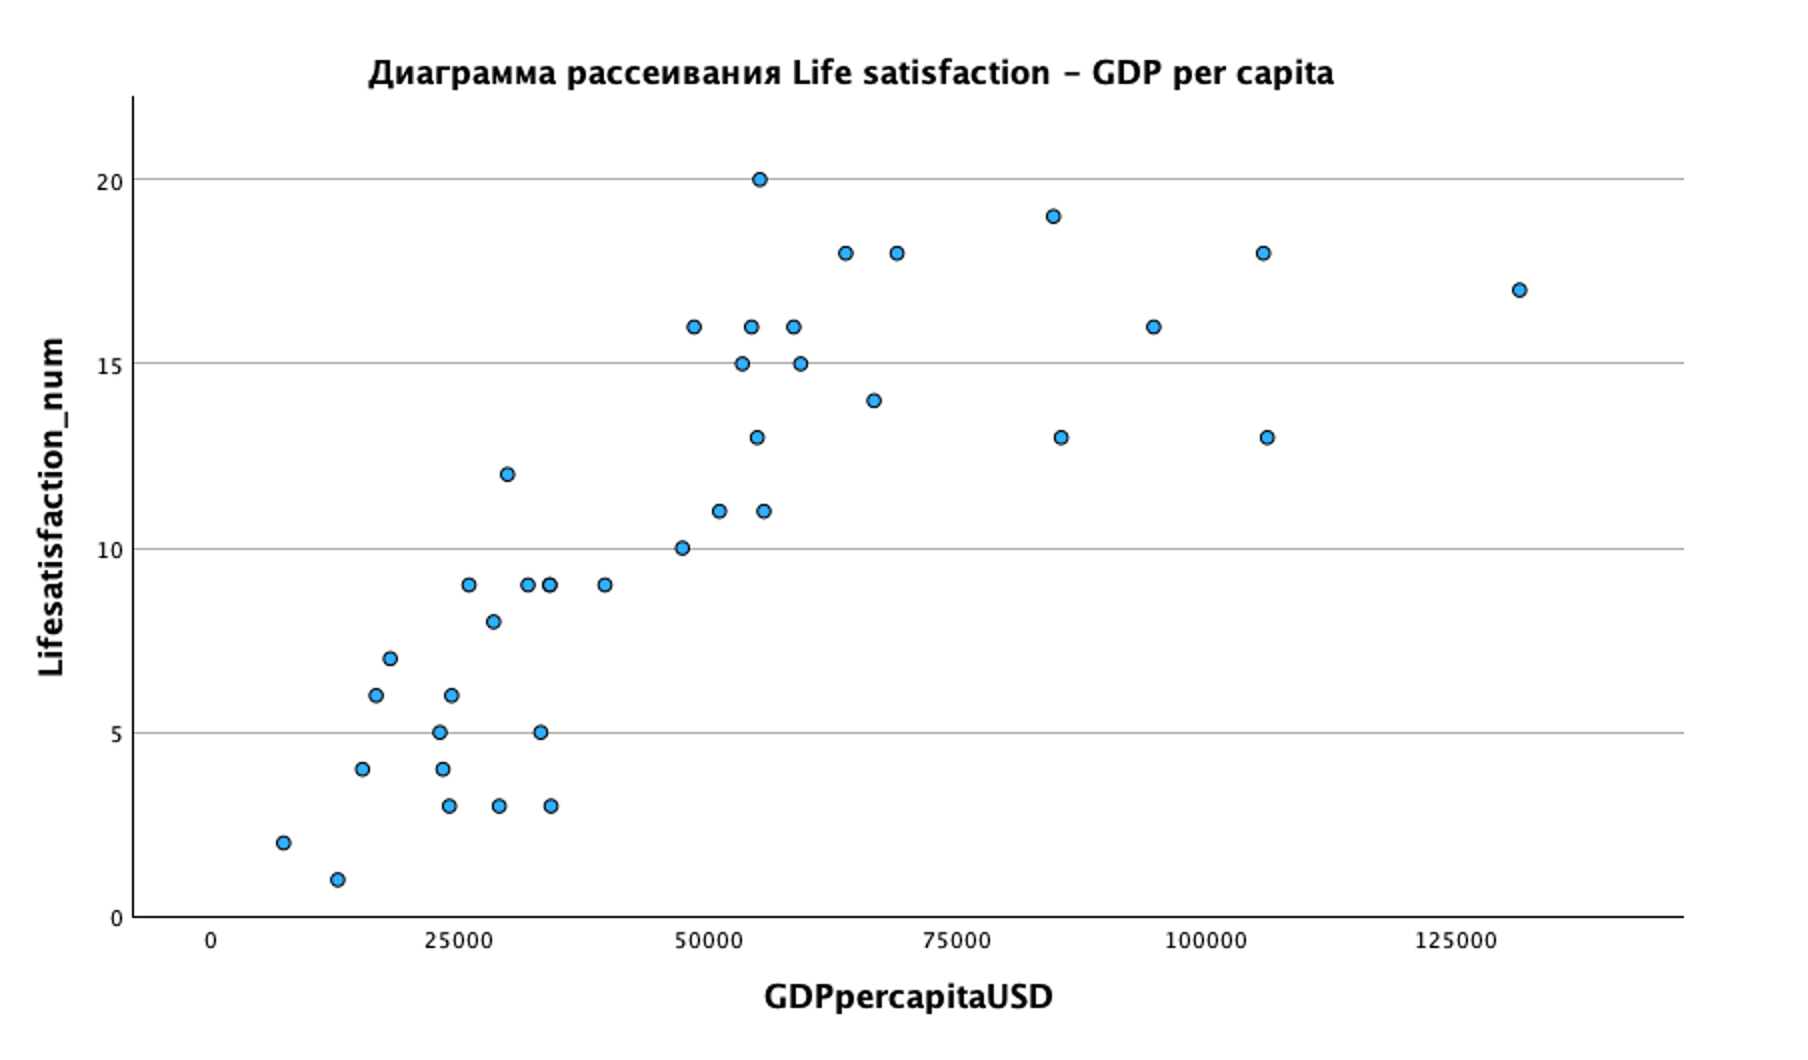

Построение диаграммы рассеяния Life satisfaction - GDP per capita было выполнено в SPSS.Здесь наблюдается положительная связь между уровнем ВВП на душу населения и удовлетворённостью жизнью. С увеличением GDP per capita значение Life satisfaction возрастает. Связь можно охарактеризовать как умеренную или близкую к сильной, так как точки располагаются по восходящей траектории, хотя присутствует некоторый разброс. Есть отдельные страны с очень высоким уровнем ВВП, которые немного выбиваются из общего облака точек, например, страна ВВП, которой по оси x>125000

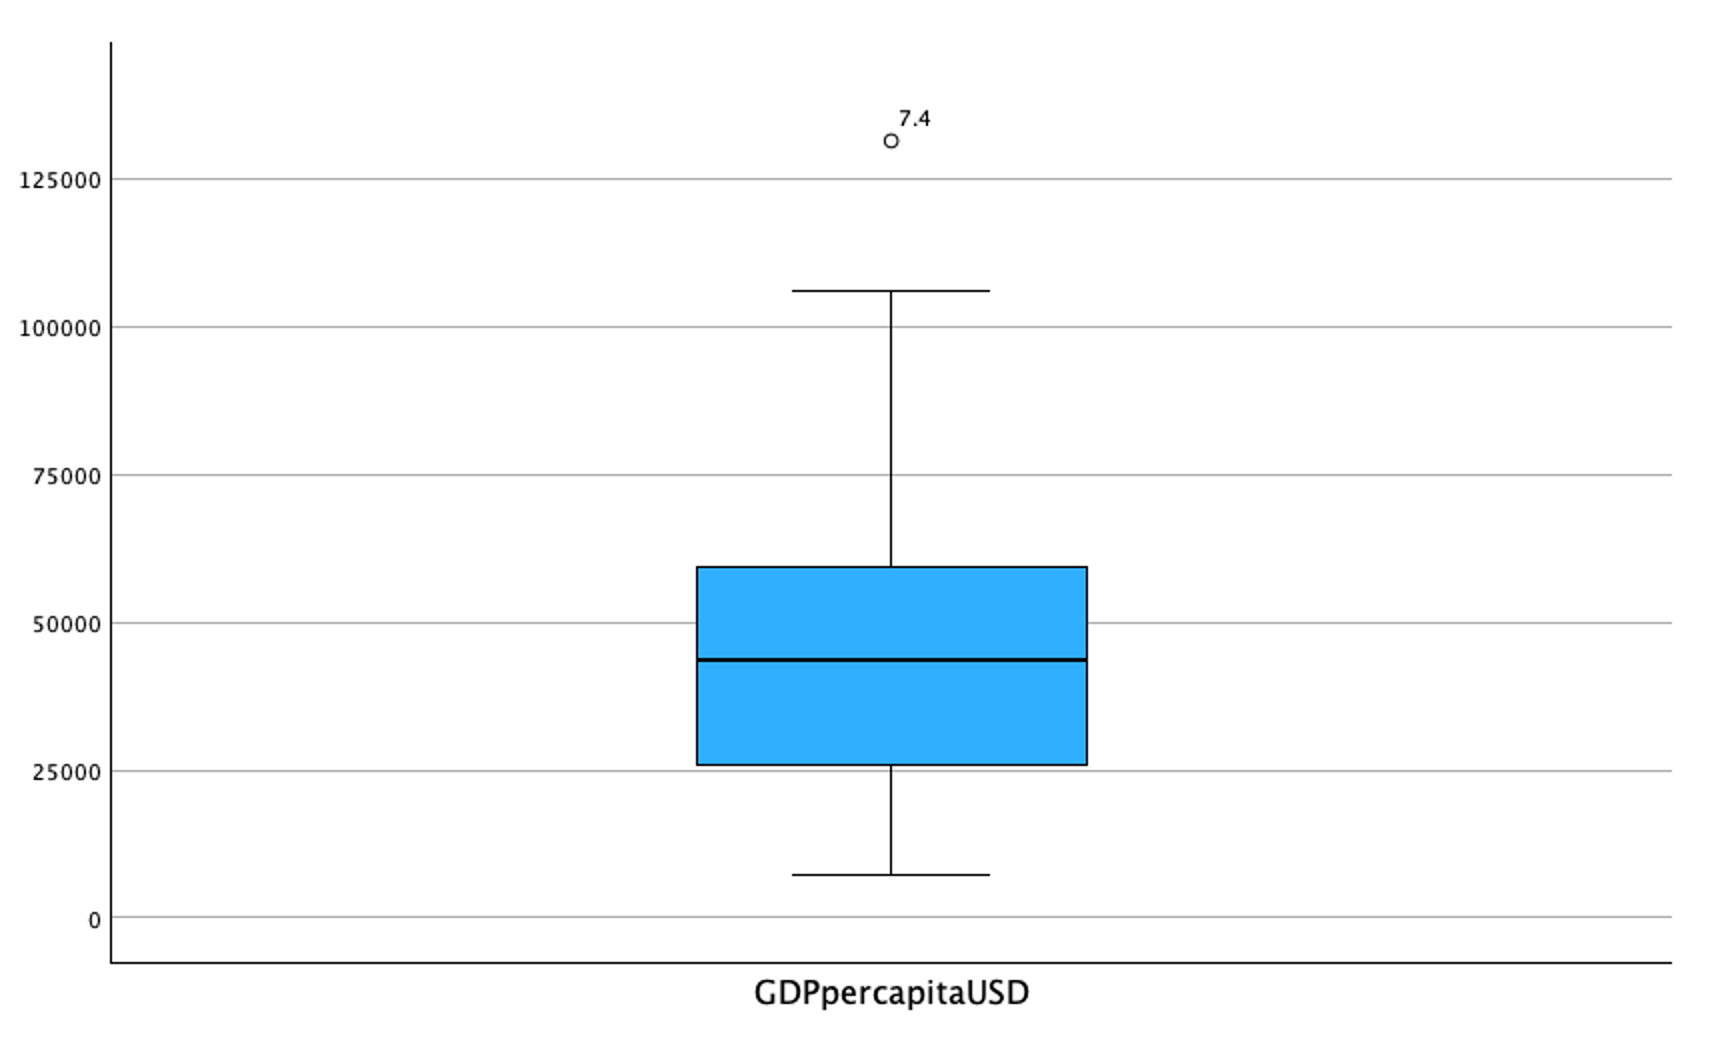

Также был построен ящик с усами для определения выбросов. Из данной диаграммы видно, что выбросом является экстремальное значение и его следует удалить из выборки

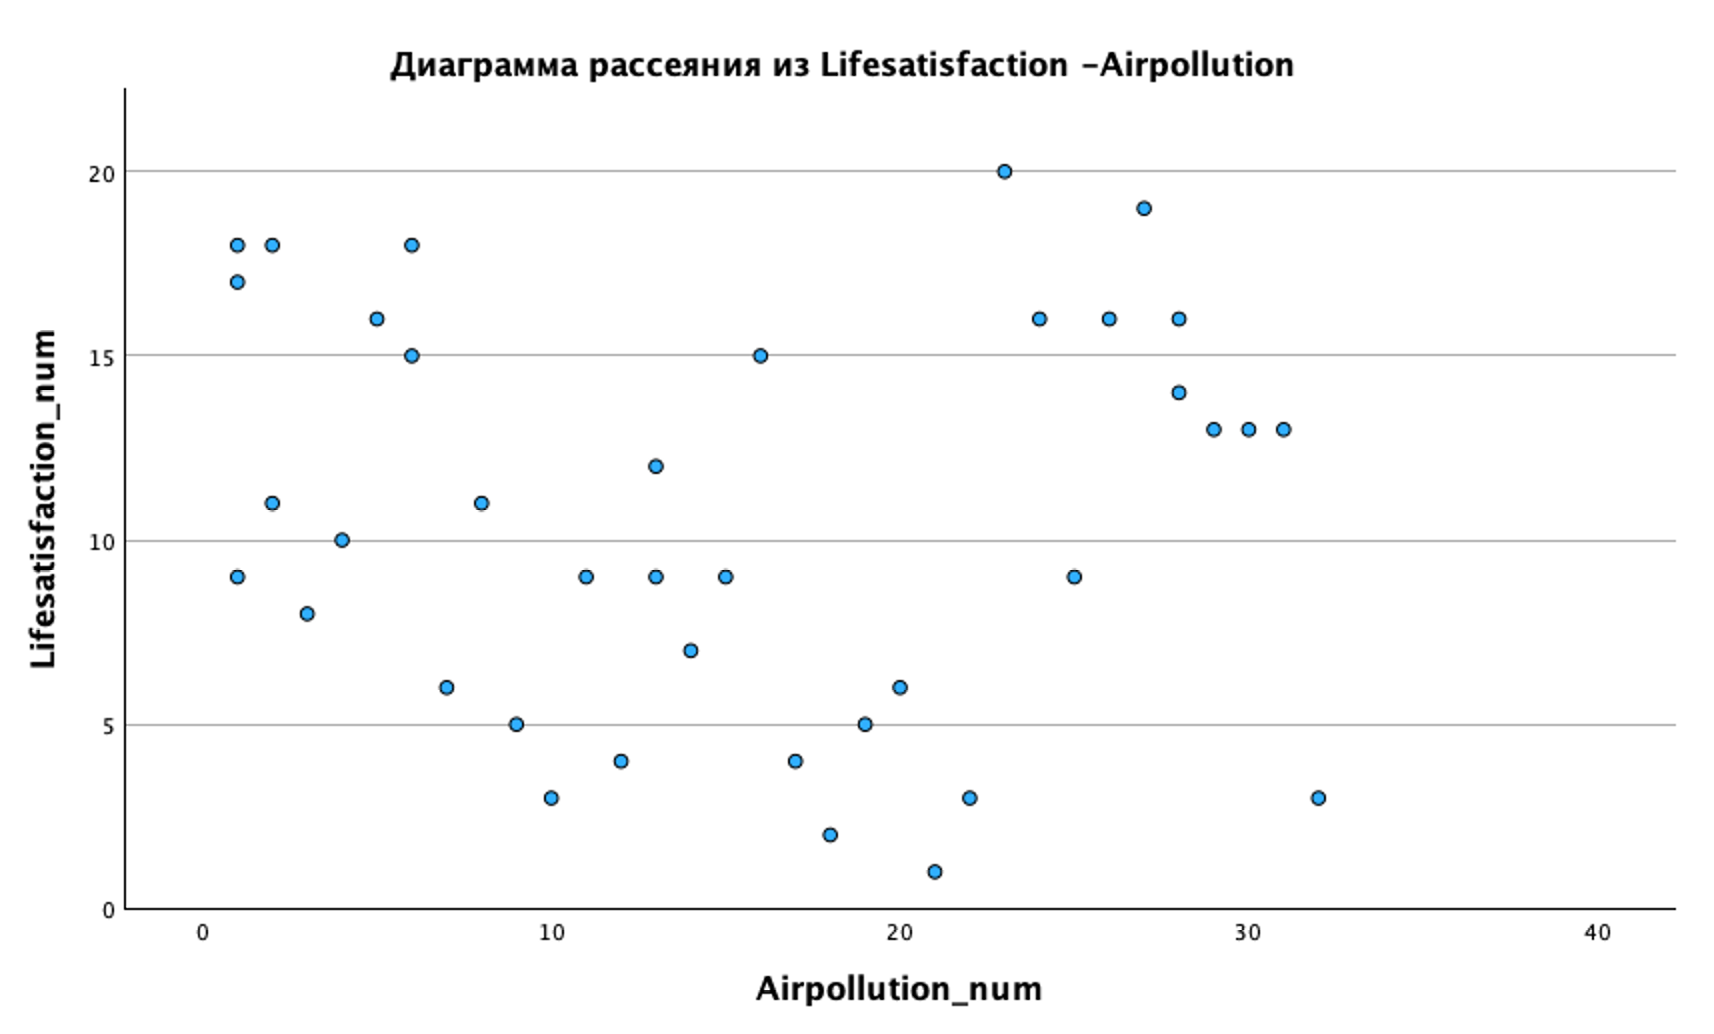

Построение диаграммы рассеяния Life satisfaction - Airpollution было выполнено в SPSS. Можно сделать вывод, что между уровнем загрязнения воздуха и удовлетворённостью жизнью наблюдается отрицательная связь умеренной силы, при этом явных выбросов немного, но возможны отдельные страны с высоким уровнем загрязнения.

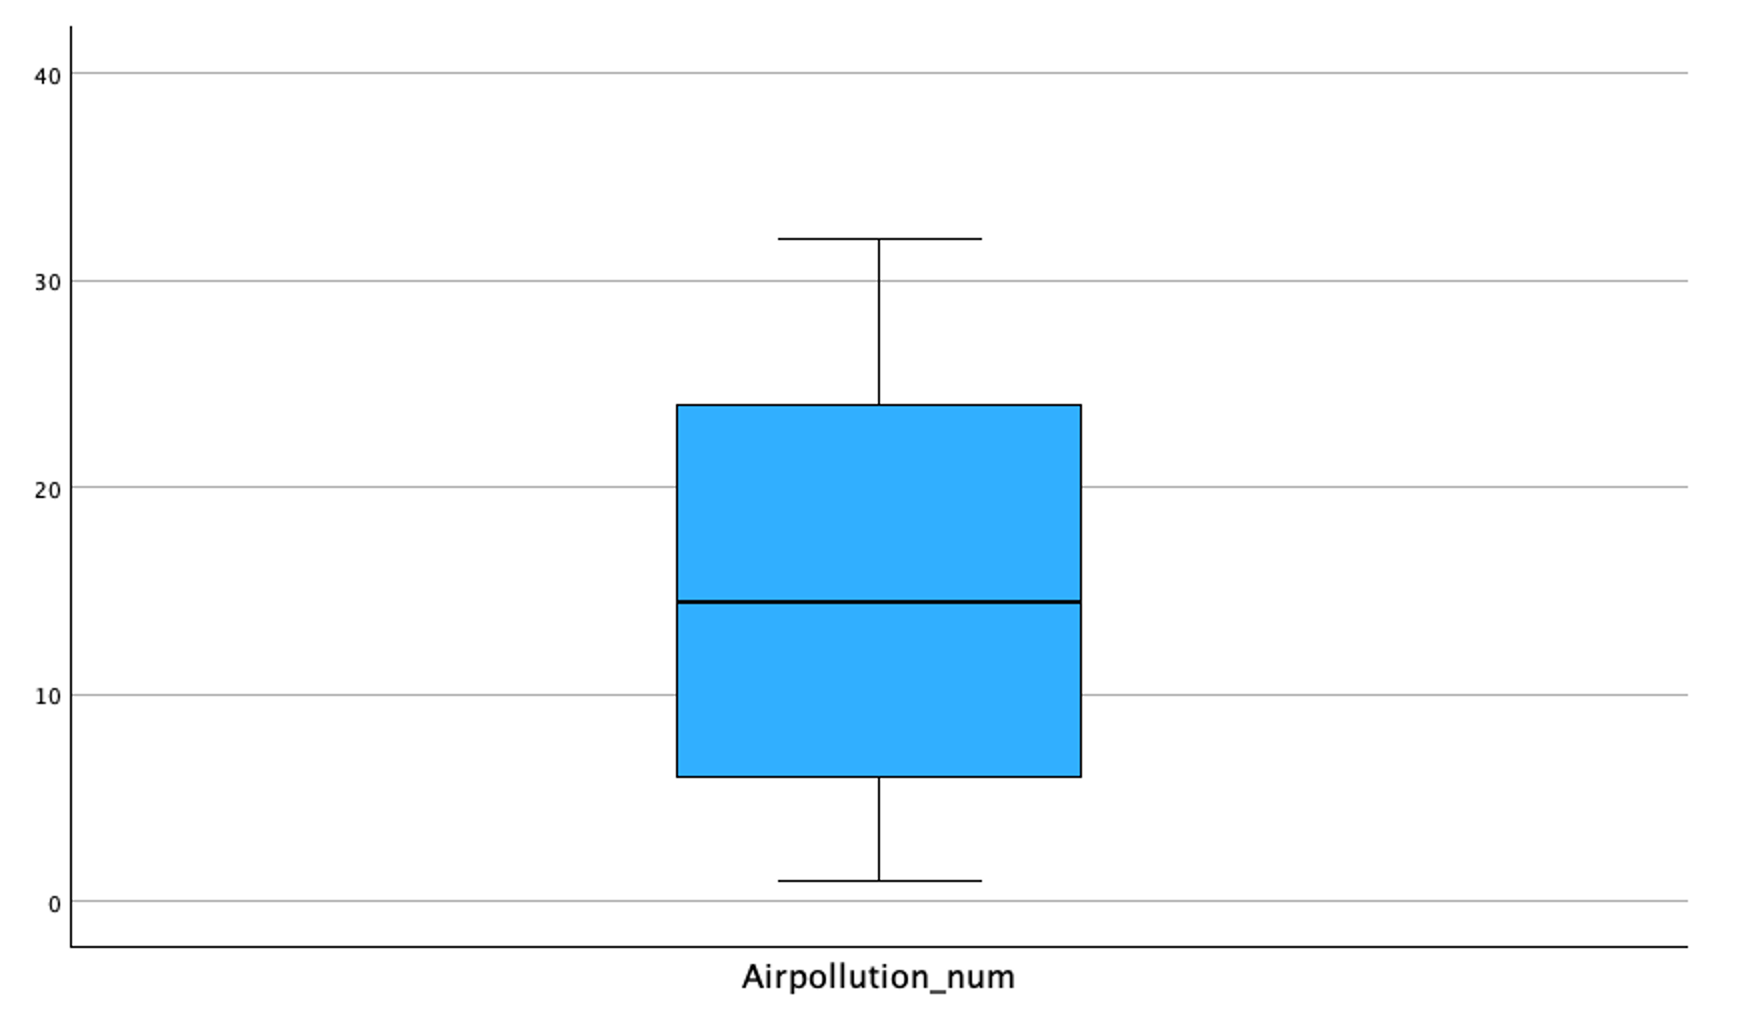

Из построенного ящика с усами можно сделать вывод, что выбросов не наблюдается.

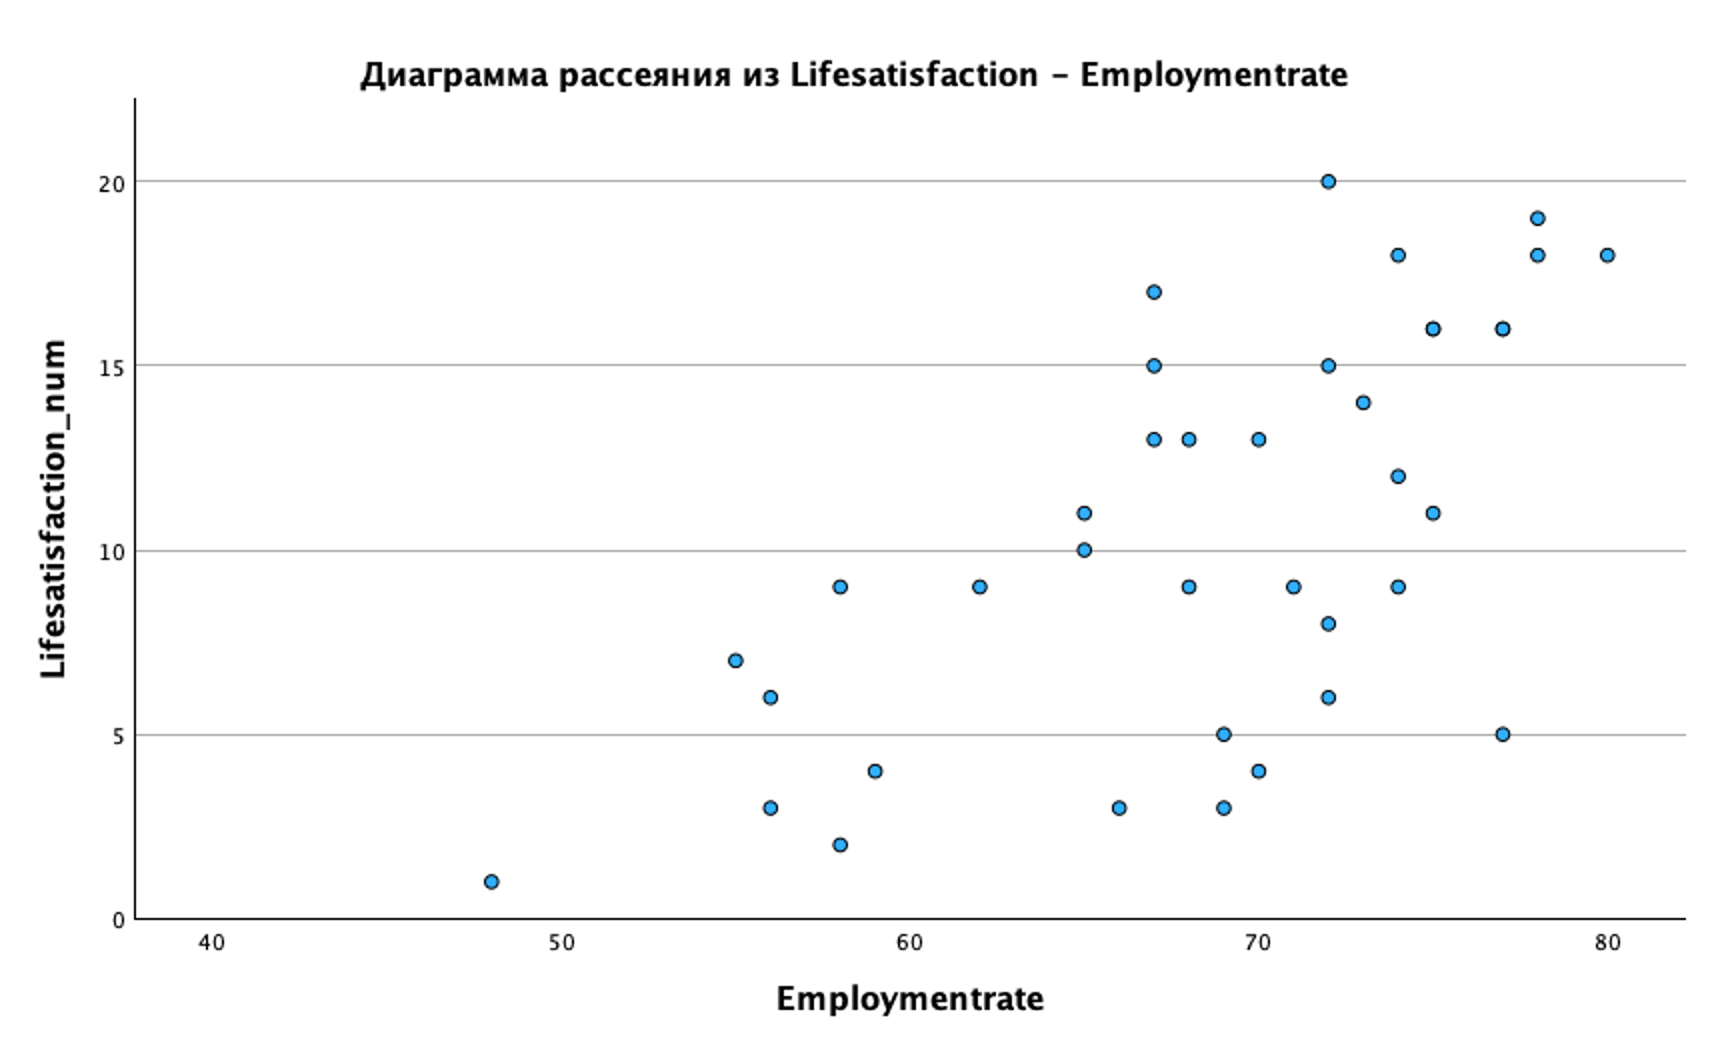

Между уровнем занятости и удовлетворённостью жизнью наблюдается положительная связь умеренной силы. Выбросом может считаться точка, находящаяся в пределах x<50

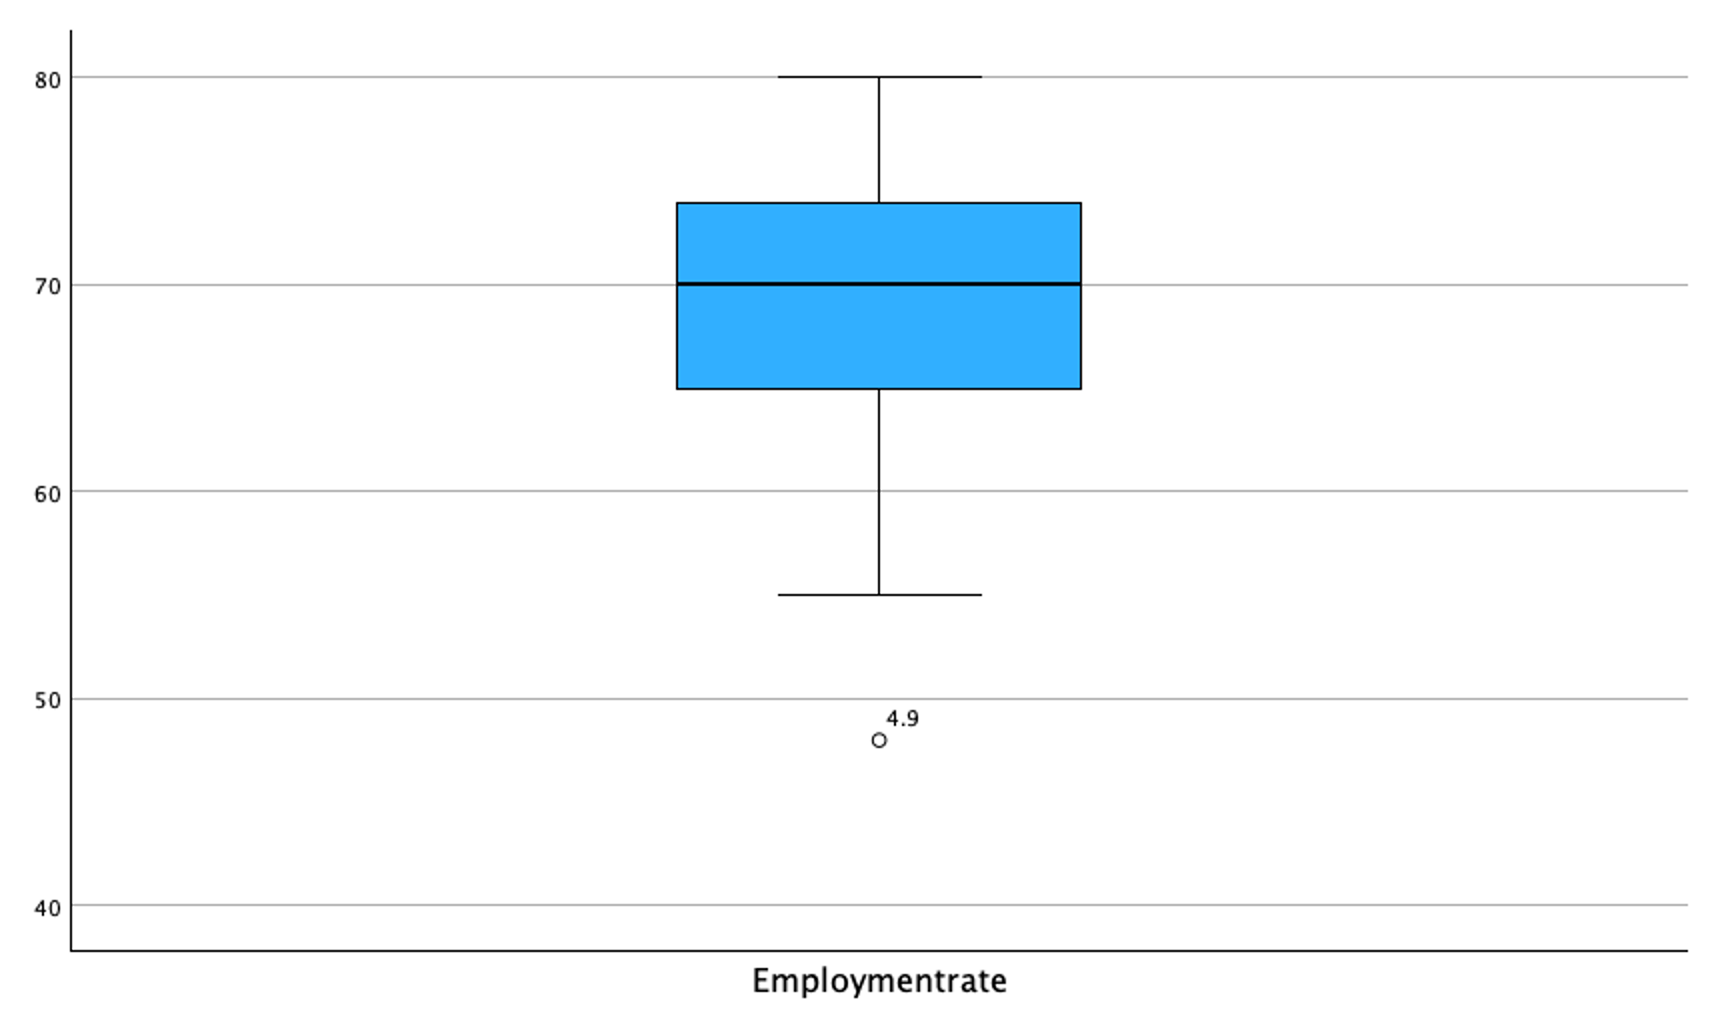

Как и было сказано выше, после построения ящика с усами можно считать экстремальным выбросом - значение, находящееся ниже предела значения 50

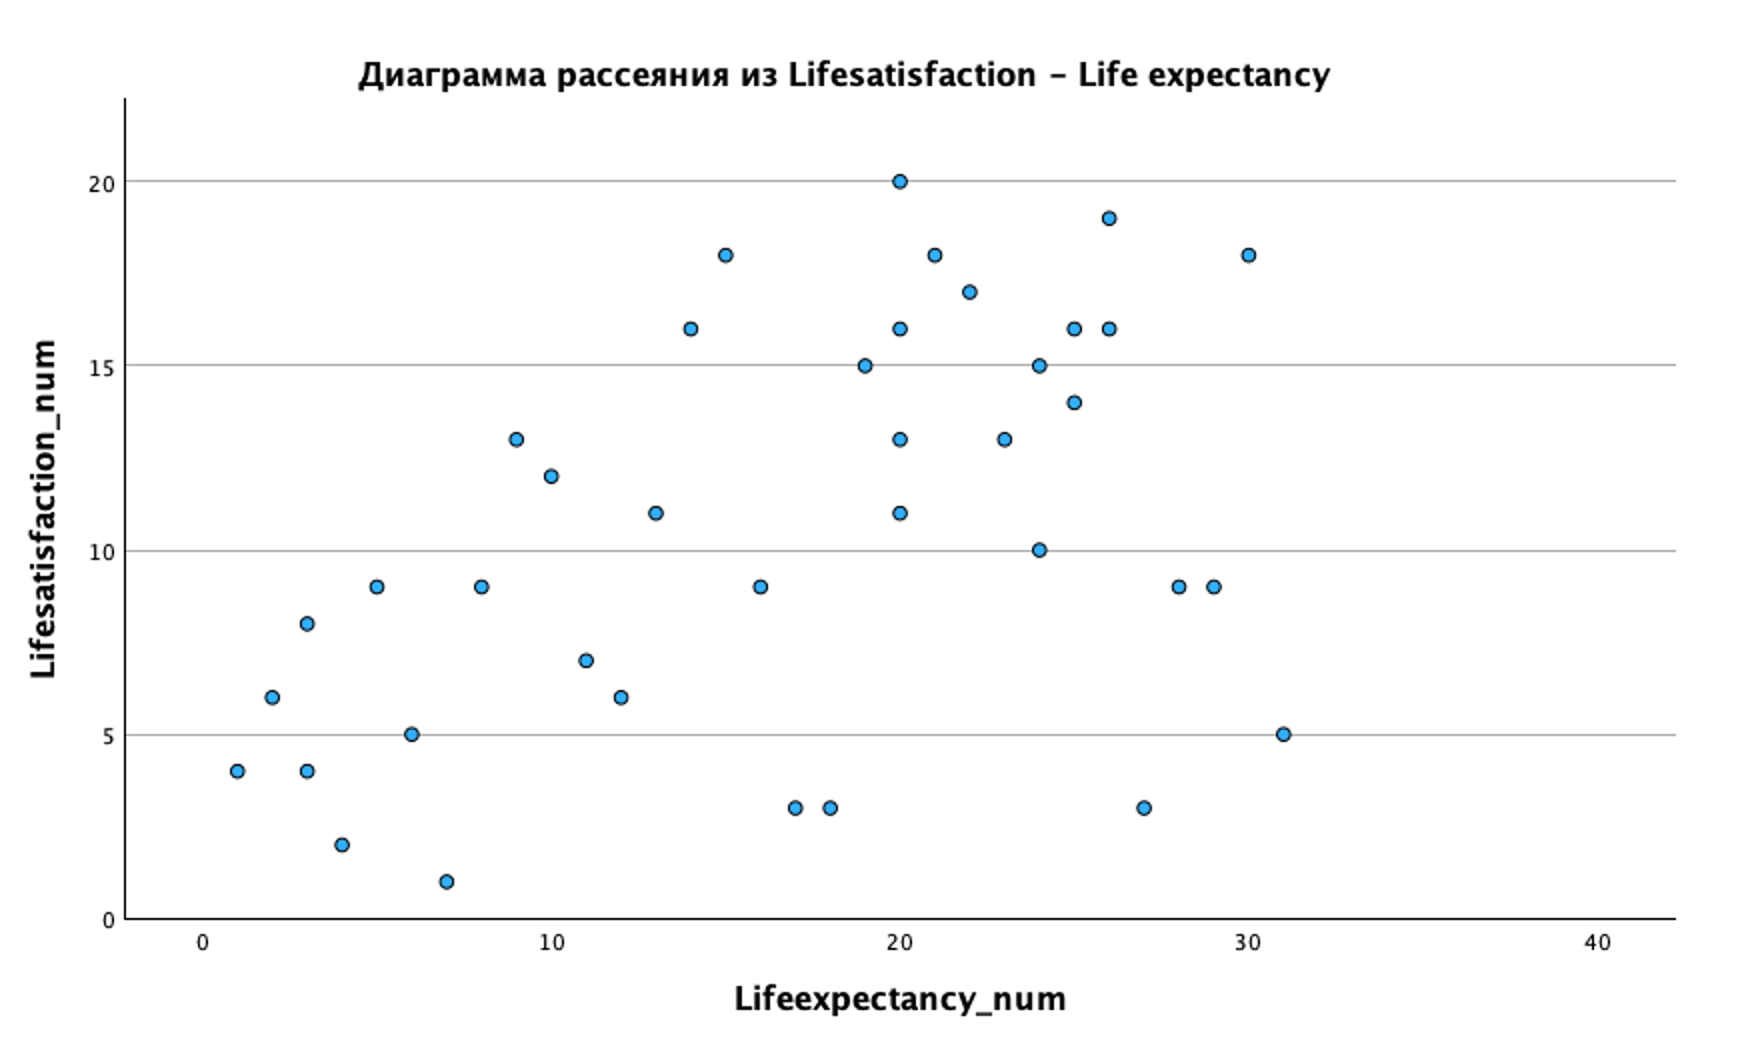

Из представленной диаграммы рассеяния можно сделать вывод, что между ожидаемой   продолжительностью   жизни и удовлетворённостью   жизнью наблюдается   положительная   и достаточно   сильная связь,   при этом выбросы   практически   отсутствуют.

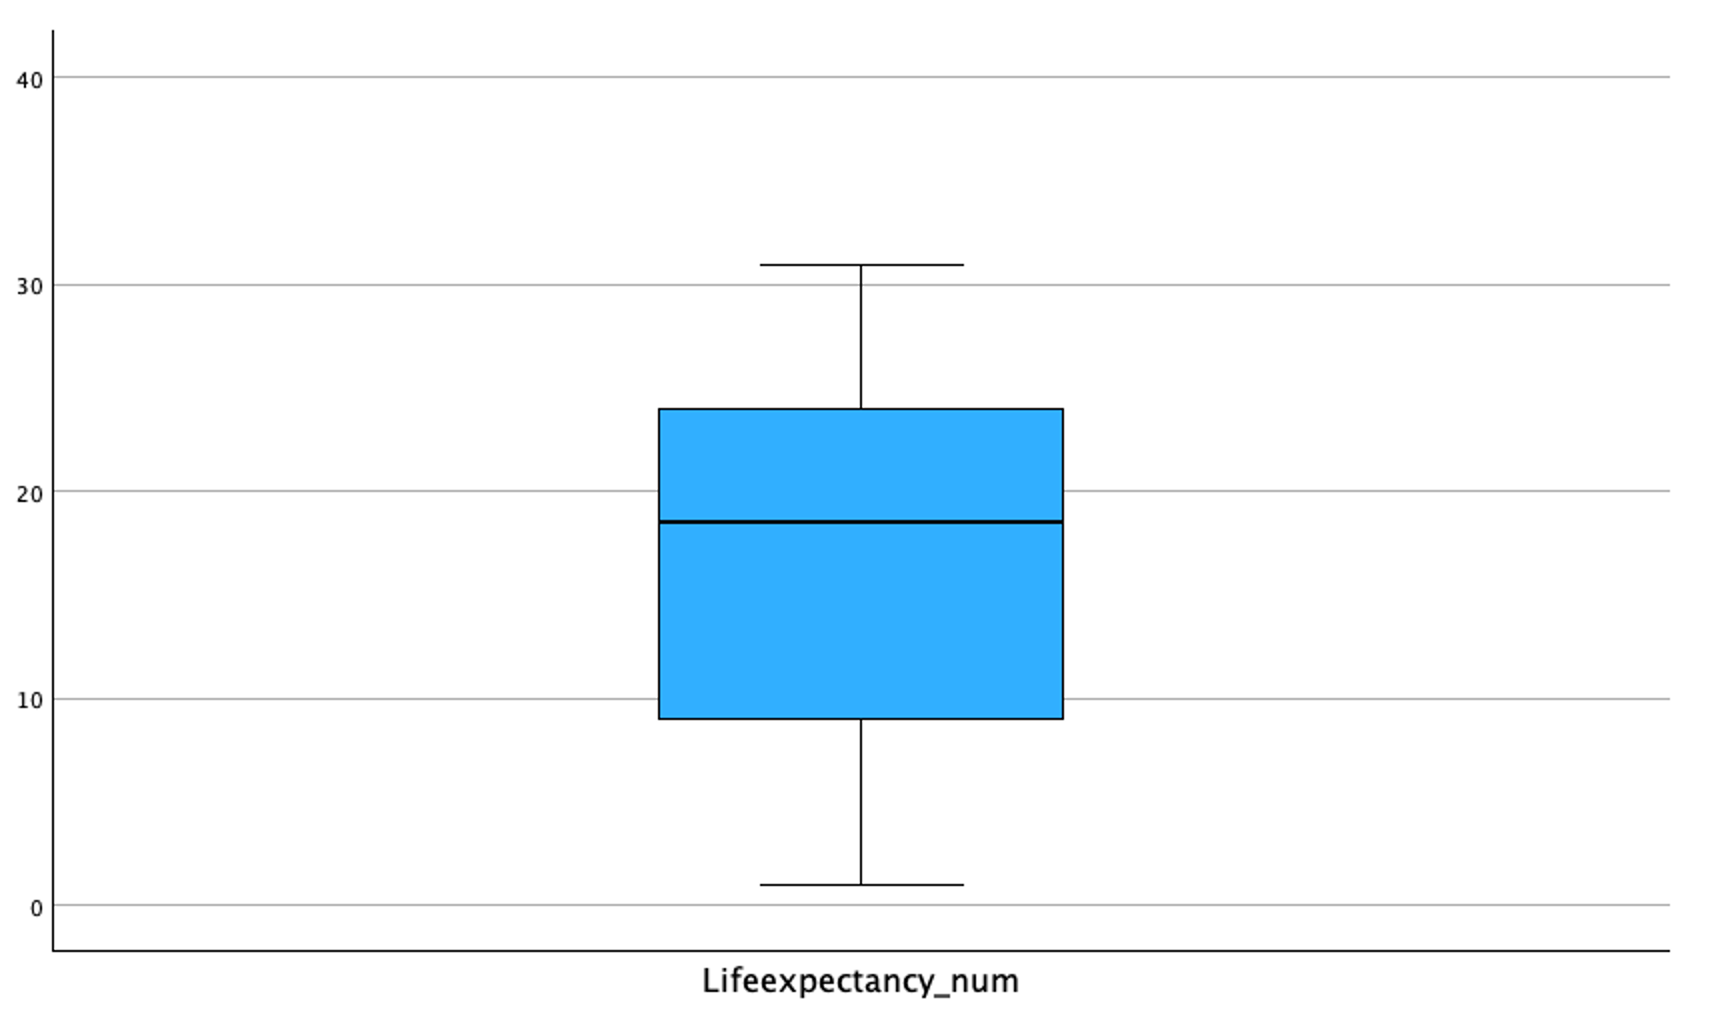

Из представленного ящика с усами видно, что экстремальных выбросов не замечено. Это означает, что значения в выборке довольно однородны.

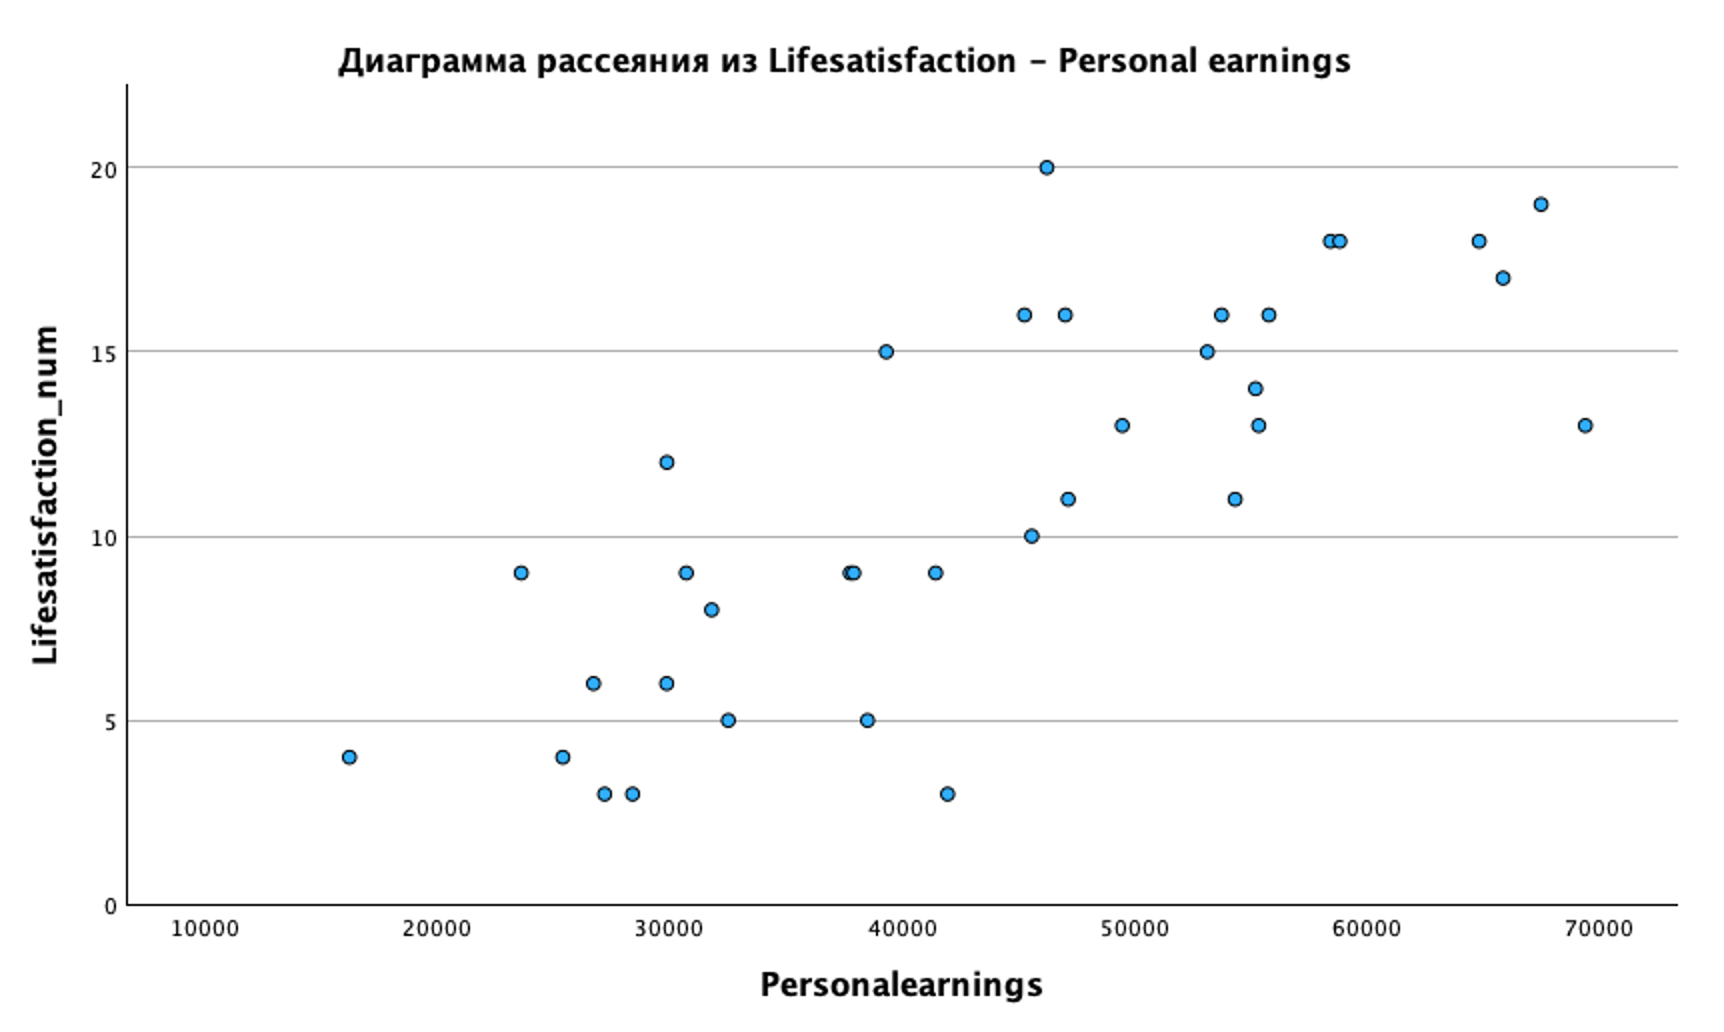

Если обратиться к диаграмме рассеяния Life Satisfaction - Personal earning, то можно заметить, что между уровнем личных доходов и удовлетворённостью жизнью наблюдается положительная, близкая к сильной связь, при этом имеются отдельные выбросы, связанные с высокими значениями доходов, например, точка в значении x=20.

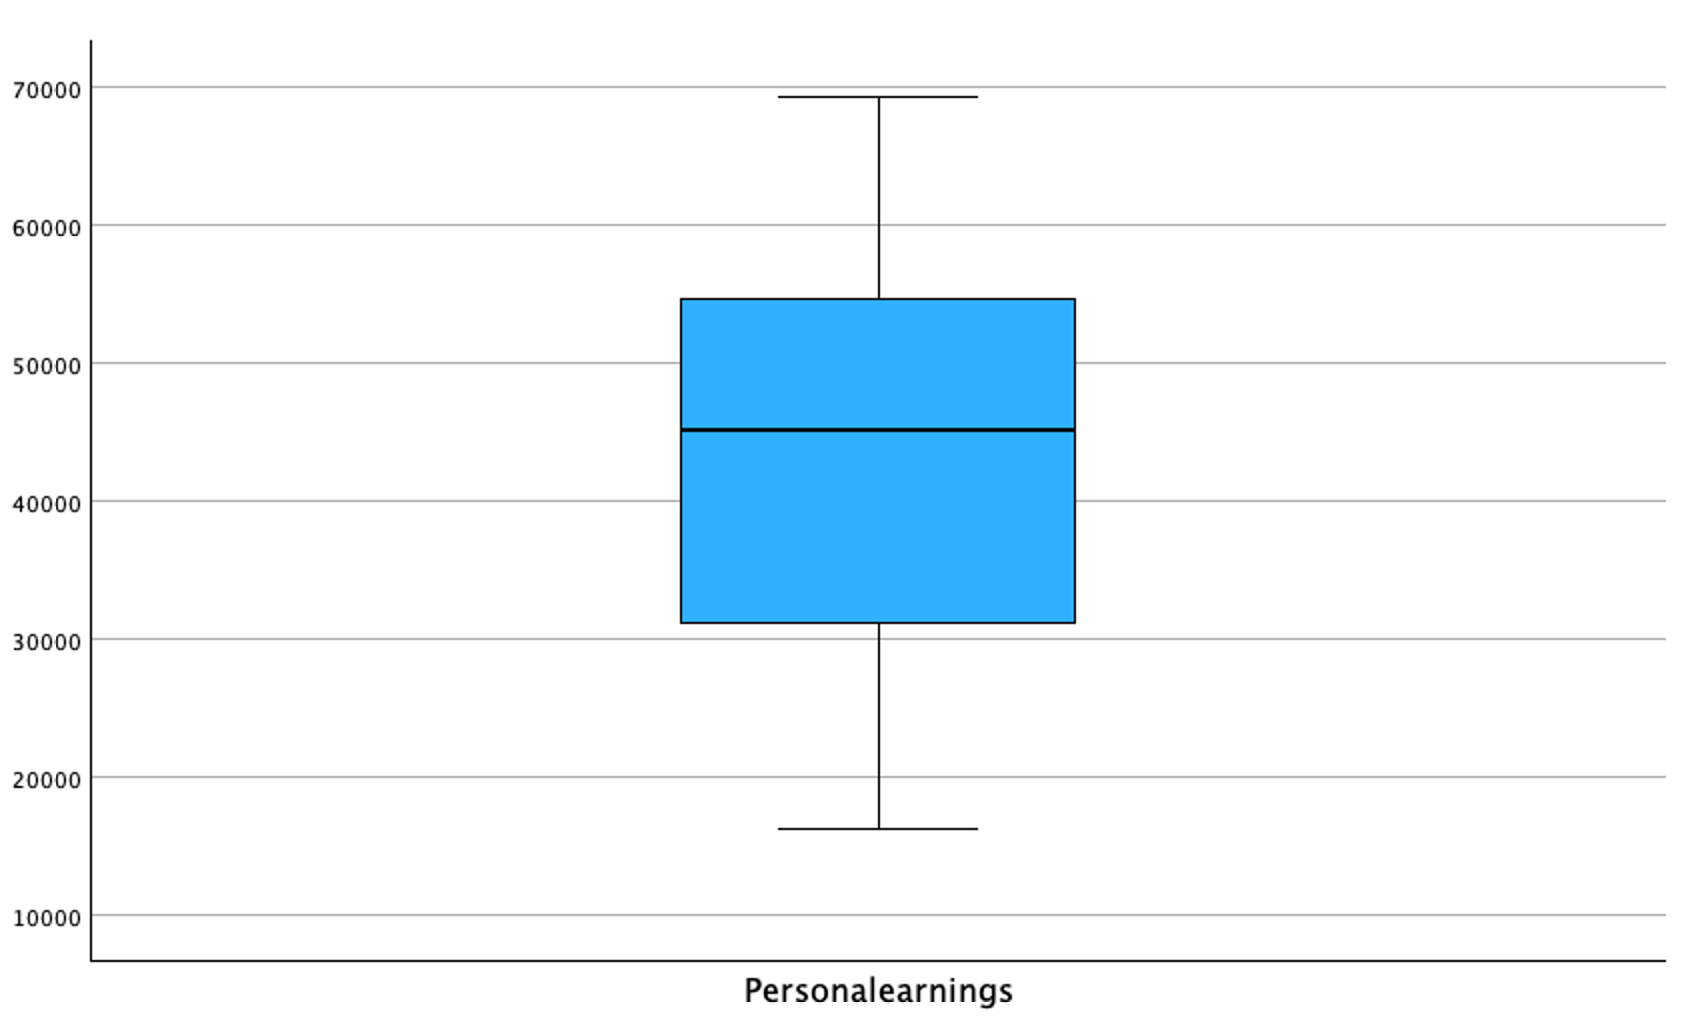

Однако если мы построим на построенный ящик с усами, то выбросов нет

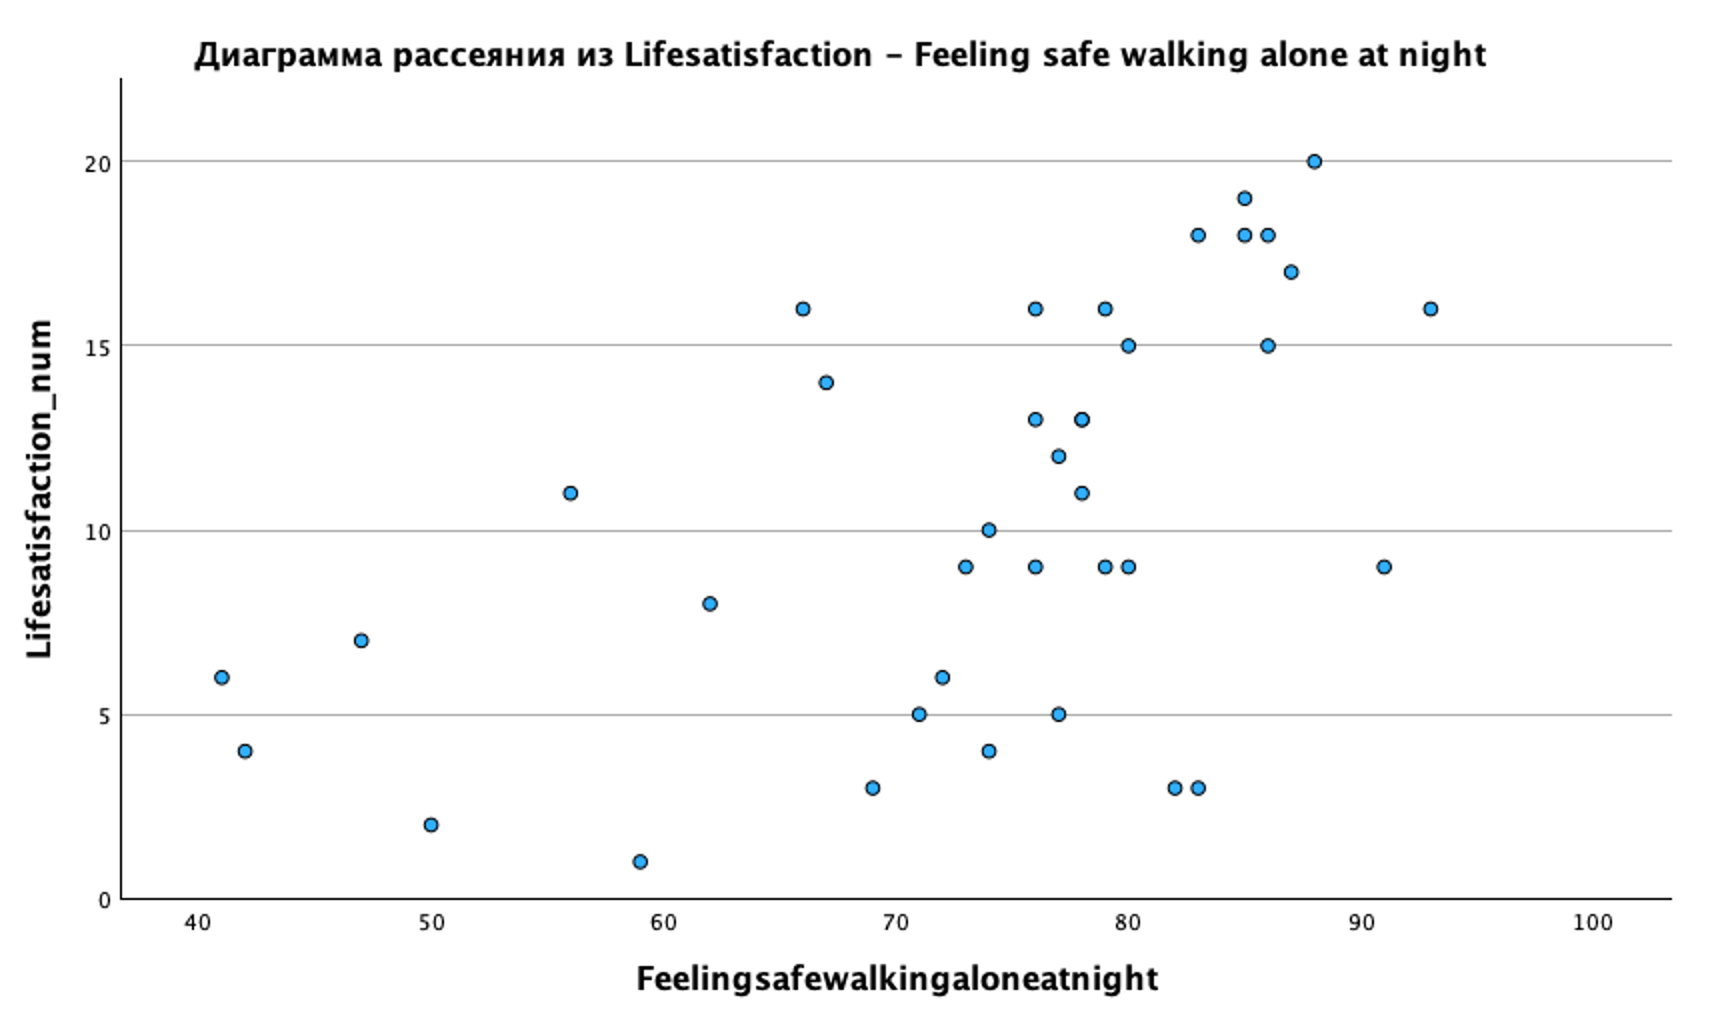

В целом здесь большинство факторов имеют положительную связь с удовлетворённостью жизнью, за исключением загрязнения воздуха, при этом наиболее сильные зависимости наблюдаются для доходов, ВВП и продолжительности жизни, а выбросы в основном связаны с экономическими показателями

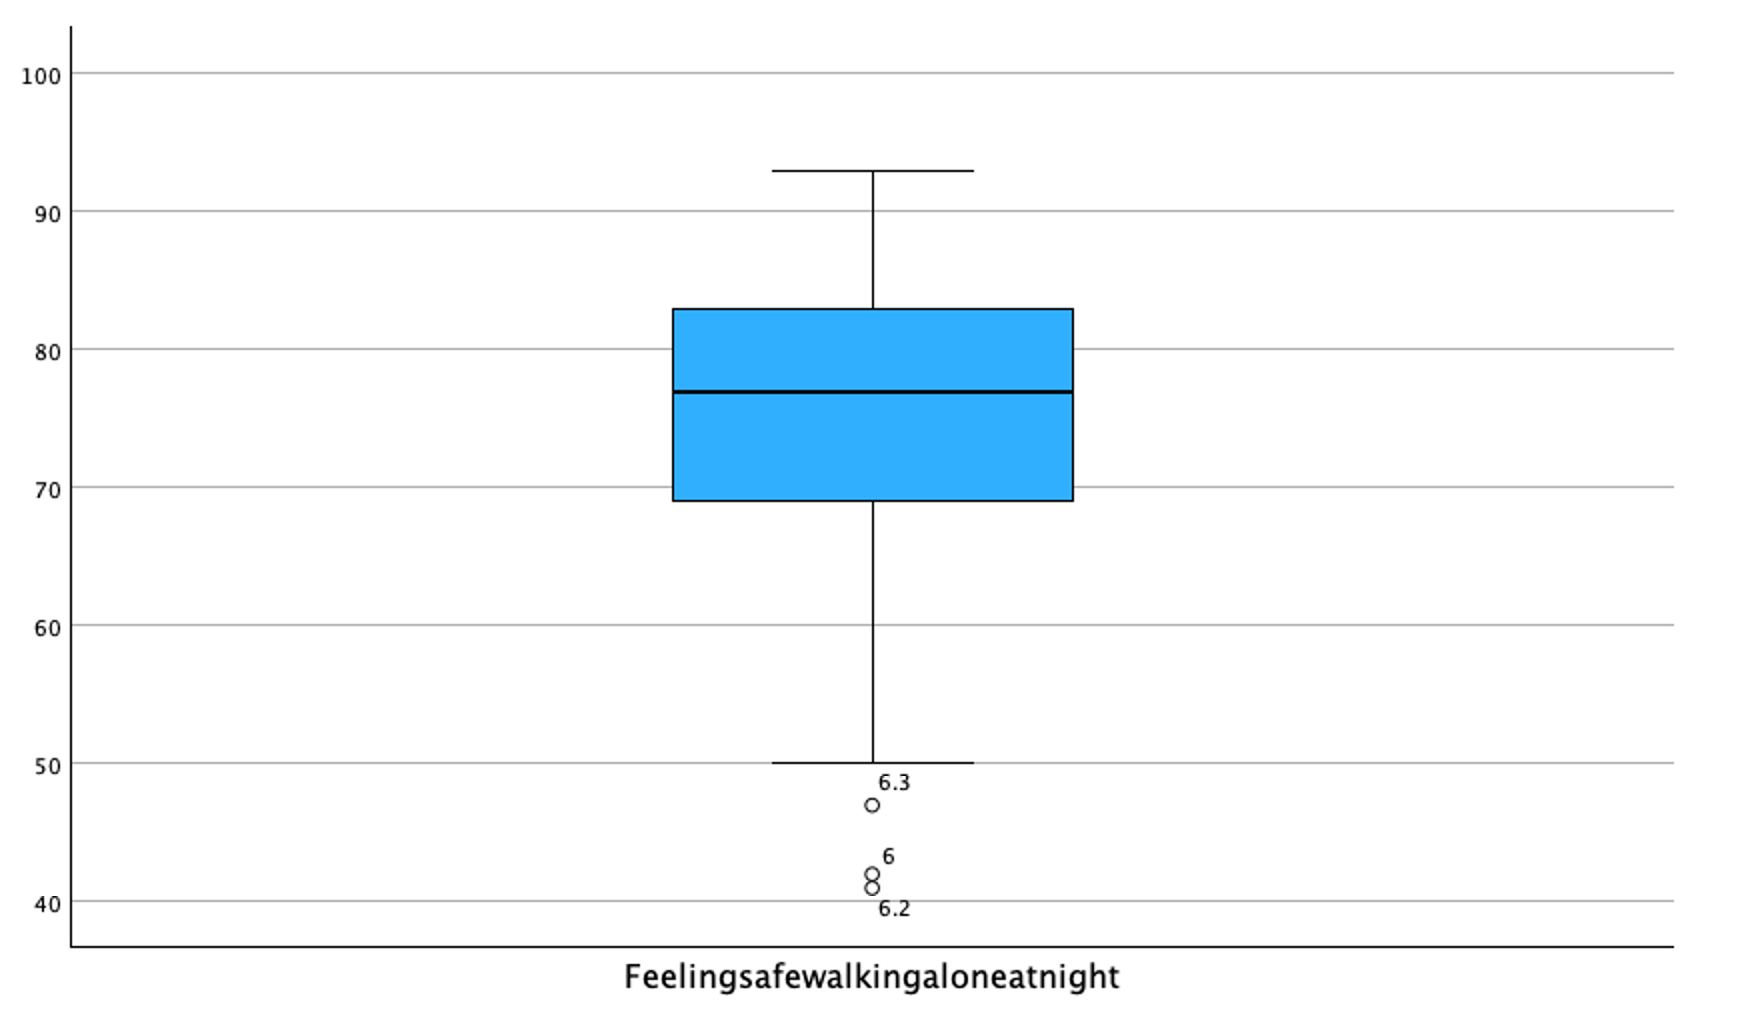

Как видно из ящика с усами в выборке имеюются экстремальные значения, которые делают ее неоднородными. В дальнейшей работе они будут исключены.

*ВЫВОД*

В целом большинство факторов имеют положительную связь с удовлетворённостью жизнью, за исключением загрязнения воздуха, при этом наиболее сильные зависимости наблюдаются для доходов, ВВП и продолжительности жизни, а выбросы в основном связаны с экономическими показателями

На отдельных диаграммах рассеяния наблюдаются точки, отклоняющиеся от общей тенденции. Такие наблюдения могут быть связаны с особенностями отдельных стран, резко отличающихся по уровню доходов, экологической ситуации или социальным условиям.
Наличие подобных выбросов может искажать величины коэффициентов корреляции, поэтому далее был проведён анализ до и после удаления аномальных наблюдений.

*МАТРИЦА ПАРНЫХ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ ДО УДАЛЕНИЯ ВЫБРОСОВ*

Для количественной оценки силы и направления линейных связей между переменными была построена матрица парных коэффициентов корреляции Пирсона.

КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - GDP per capita

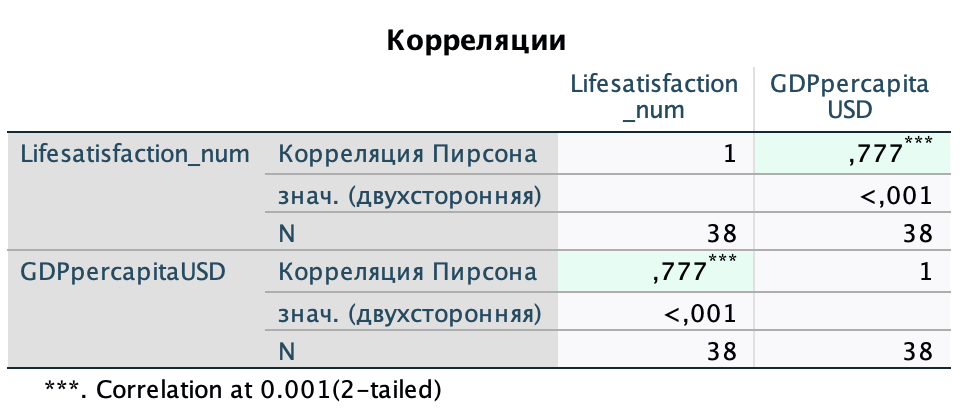

Между переменными Lifesatisfaction_num и GDP per capita наблюдается сильная положительная корреляционная связь, так как коэффициент корреляции Пирсона составляет r = 0,777. Это означает, что с увеличением уровня ВВП на душу населения повышается уровень удовлетворённости жизнью. Полученная зависимость является статистически значимой, поскольку уровень значимости p < 0,001, что позволяет сделать вывод о надёжности выявленной связи. Следовательно, GDP per capita можно рассматривать как один из наиболее значимых факторов, влияющих на уровень удовлетворённости жизнью.


КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - Airpollution

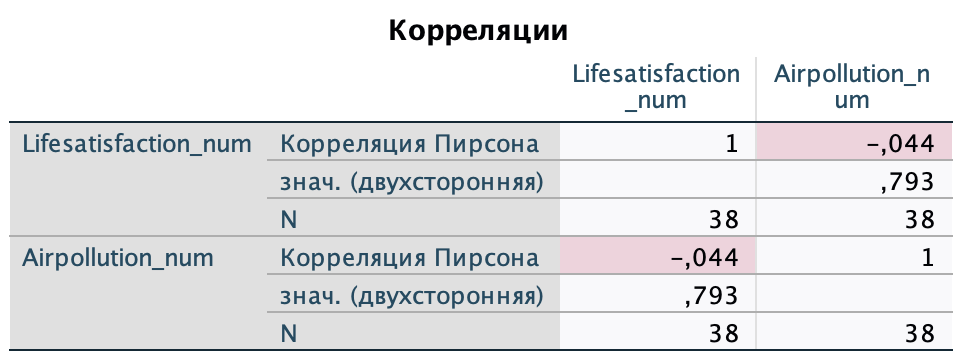

Между переменными Lifesatisfaction_num и Airpollution_num наблюдается очень слабая отрицательная корреляционная связь, так как коэффициент корреляции Пирсона составляет r = -0,044. Это означает, что зависимость между уровнем загрязнения воздуха и удовлетворённостью жизнью практически отсутствует. Полученная связь является статистически незначимой, поскольку уровень значимости p = 0,793 значительно превышает стандартный уровень значимости 0,05. Следовательно, нельзя сделать вывод о наличии существенного влияния загрязнения воздуха на уровень удовлетворённости жизнью в данной выборке.

КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - Employmentrate

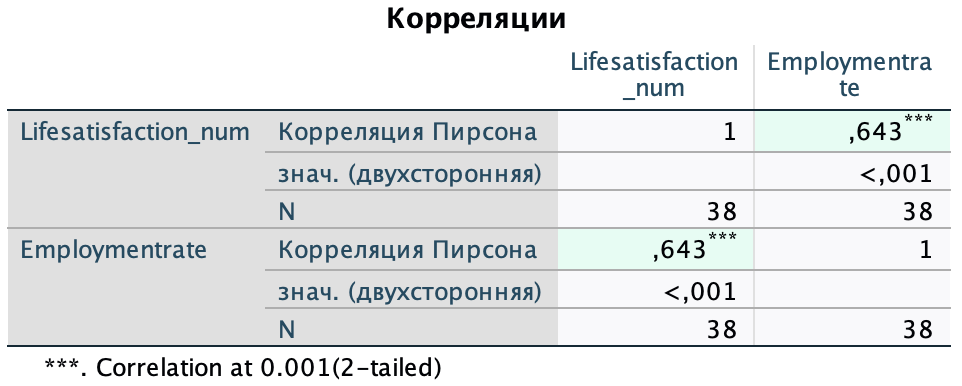

Между переменными Lifesatisfaction_num и Employment rate наблюдается положительная корреляционная связь средней силы, так как коэффициент корреляции Пирсона составляет r = 0,643. Это означает, что с увеличением уровня занятости возрастает уровень удовлетворённости жизнью. Полученная связь является статистически значимой, поскольку уровень значимости p < 0,001, что свидетельствует о надёжности выявленной зависимости. Следовательно, уровень занятости можно рассматривать как значимый фактор, влияющий на удовлетворённость жизнью.

КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - Lifeexpectancy

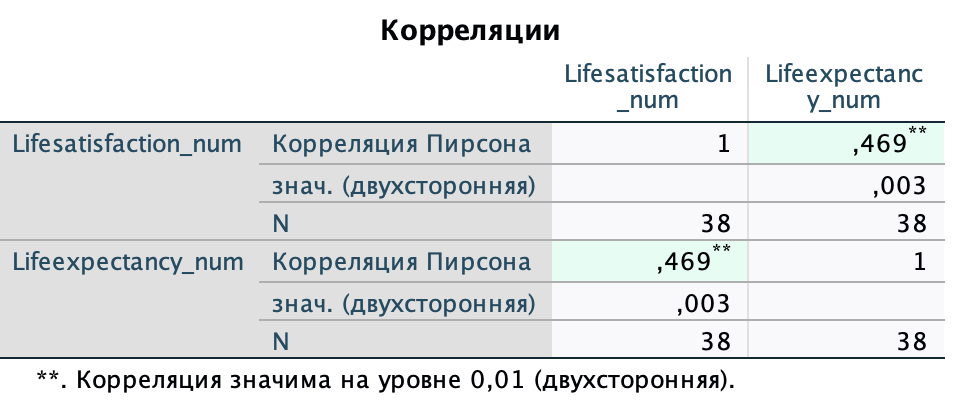

Между переменными Lifesatisfaction_num и Lifeexpectancy_num наблюдается положительная корреляционная связь средней силы, так как коэффициент корреляции Пирсона составляет r = 0,469. Это означает, что с увеличением ожидаемой продолжительности жизни повышается уровень удовлетворённости жизнью. Полученная связь является статистически значимой, поскольку уровень значимости p = 0,003 меньше 0,01, что подтверждает надёжность выявленной зависимости. Следовательно, ожидаемая продолжительность жизни является значимым фактором, влияющим на уровень удовлетворённости жизнью.

КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - Personal earnings

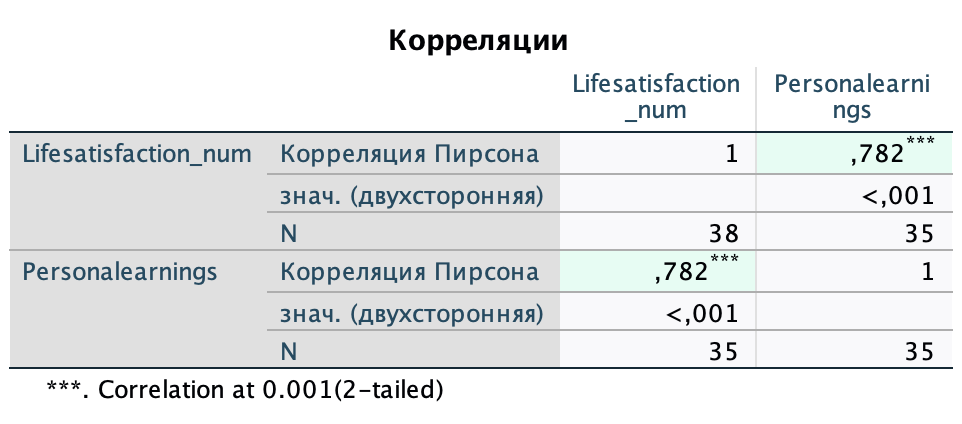

Между переменными Lifesatisfaction_num и Personal earnings наблюдается сильная положительная корреляционная связь, так как коэффициент корреляции Пирсона составляет r = 0,782. Это означает, что с увеличением уровня личных доходов возрастает уровень удовлетворённости жизнью. Полученная связь является статистически значимой, поскольку уровень значимости p < 0,001, что свидетельствует о высокой надёжности выявленной зависимости. Следовательно, личные доходы можно рассматривать как один из наиболее значимых факторов, влияющих на уровень удовлетворённости жизнью. Следует отметить, что число наблюдений по данной переменной меньше (N = 35), что связано с наличием пропущенных значений, однако это не оказывает существенного влияния на общий вывод о силе и значимости связи.

КОРРЕЛЯЦИИ МЕЖДУ Lifesatisfaction - Feeling safe walking alone at night

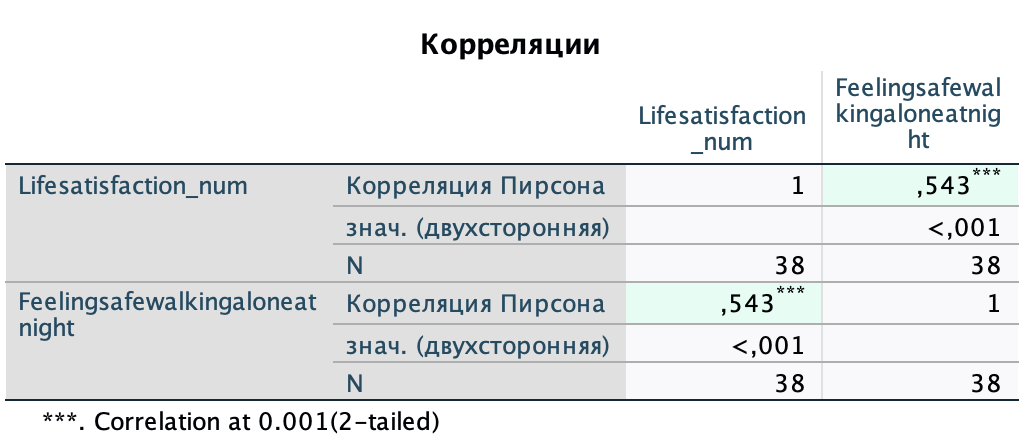

Между переменными Lifesatisfaction_num и Feeling safe walking alone at night наблюдается положительная корреляционная связь средней силы, так как коэффициент корреляции Пирсона составляет r = 0,543. Это означает, что с увеличением уровня ощущения безопасности возрастает уровень удовлетворённости жизнью. Полученная связь является статистически значимой, поскольку уровень значимости p < 0,001, что свидетельствует о надёжности выявленной зависимости. Следовательно, ощущение безопасности можно рассматривать как значимый фактор, влияющий на уровень удовлетворённости жизнью.


*ДИАГРАММЫ РАССЕЯНИЯ ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ*

На следующем этапе анализа были удалены аномальные наблюдения (выбросы, если они были видны в ящиках с усами), после чего были повторно построены парные поля корреляции.

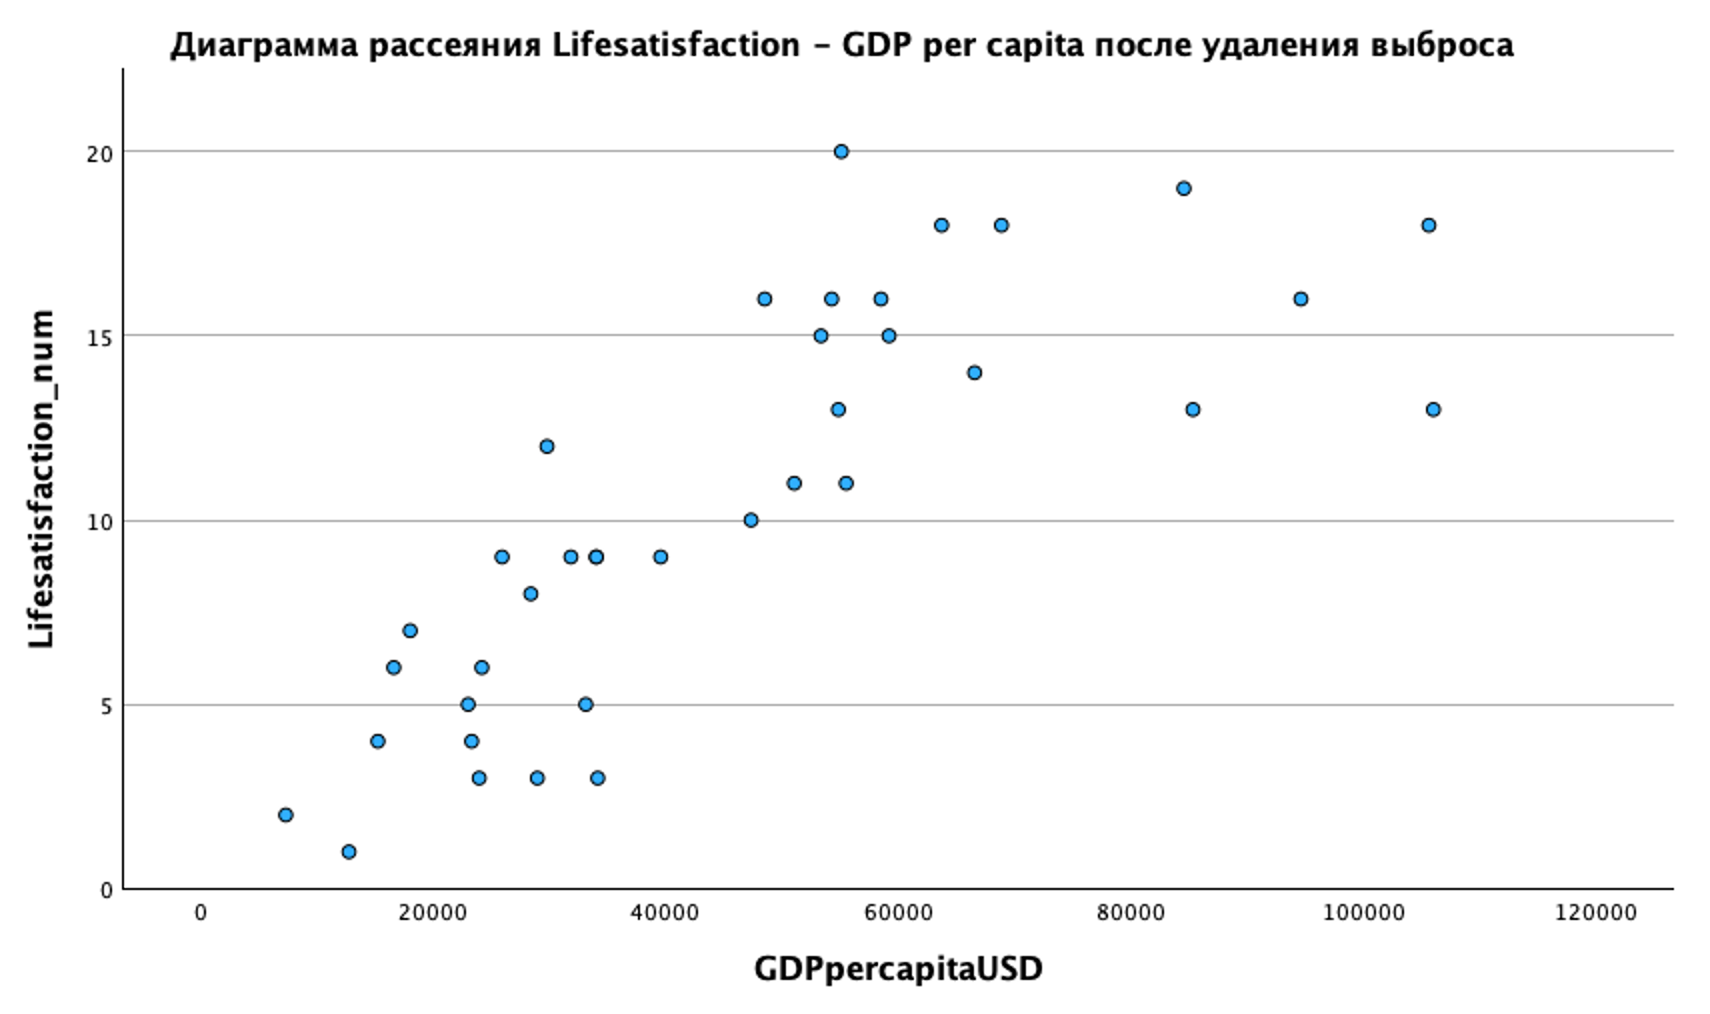

После удаления выброса (страны с экстремально высоким значением ВВП на душу населения — Люксембург) характер связи между переменными Lifesatisfaction_num и GDP per capita изменился. Связь стала более чёткой и наглядной, точки распределены более равномерно, а общий разброс значений уменьшился. Линия тренда стала более выраженной, что свидетельствует о более стабильной положительной зависимости между переменными. Удаление выброса позволило снизить искажение результатов и более точно отразить реальную взаимосвязь между уровнем ВВП на душу населения и удовлетворённостью жизнью.

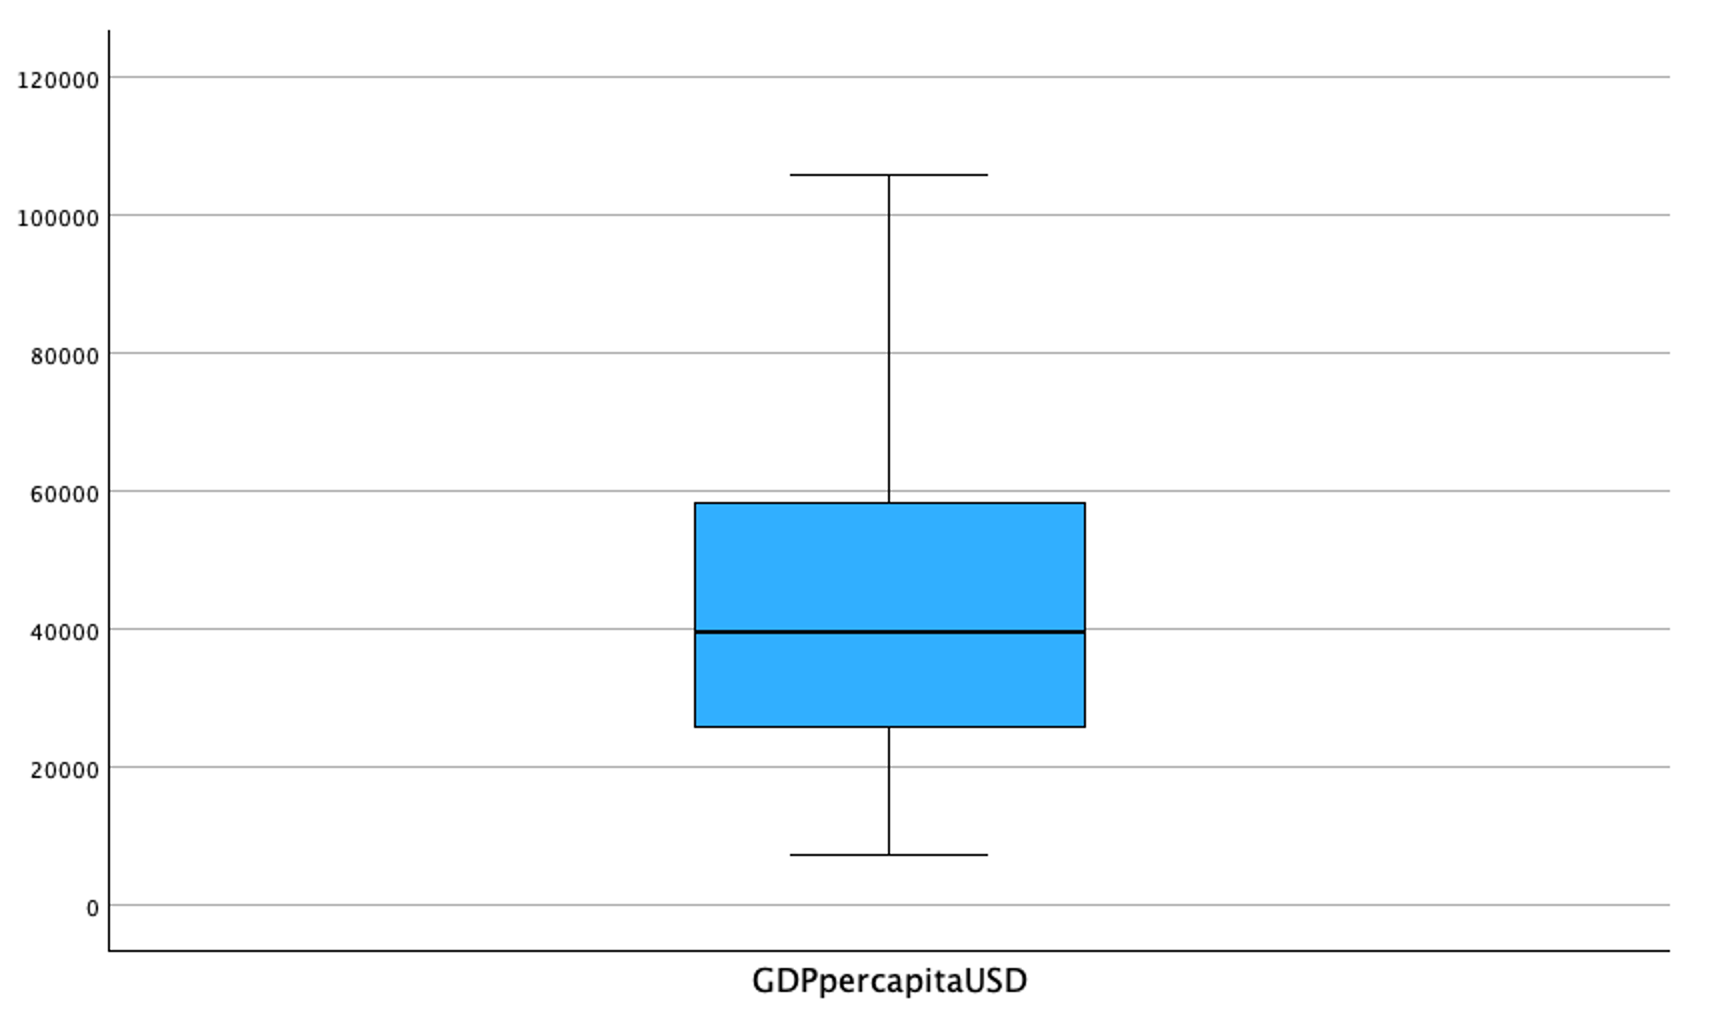

Видно, что после удаления выбросов ящик с усами не выявил больше никаких выбросов, то есть выборка стала однородной

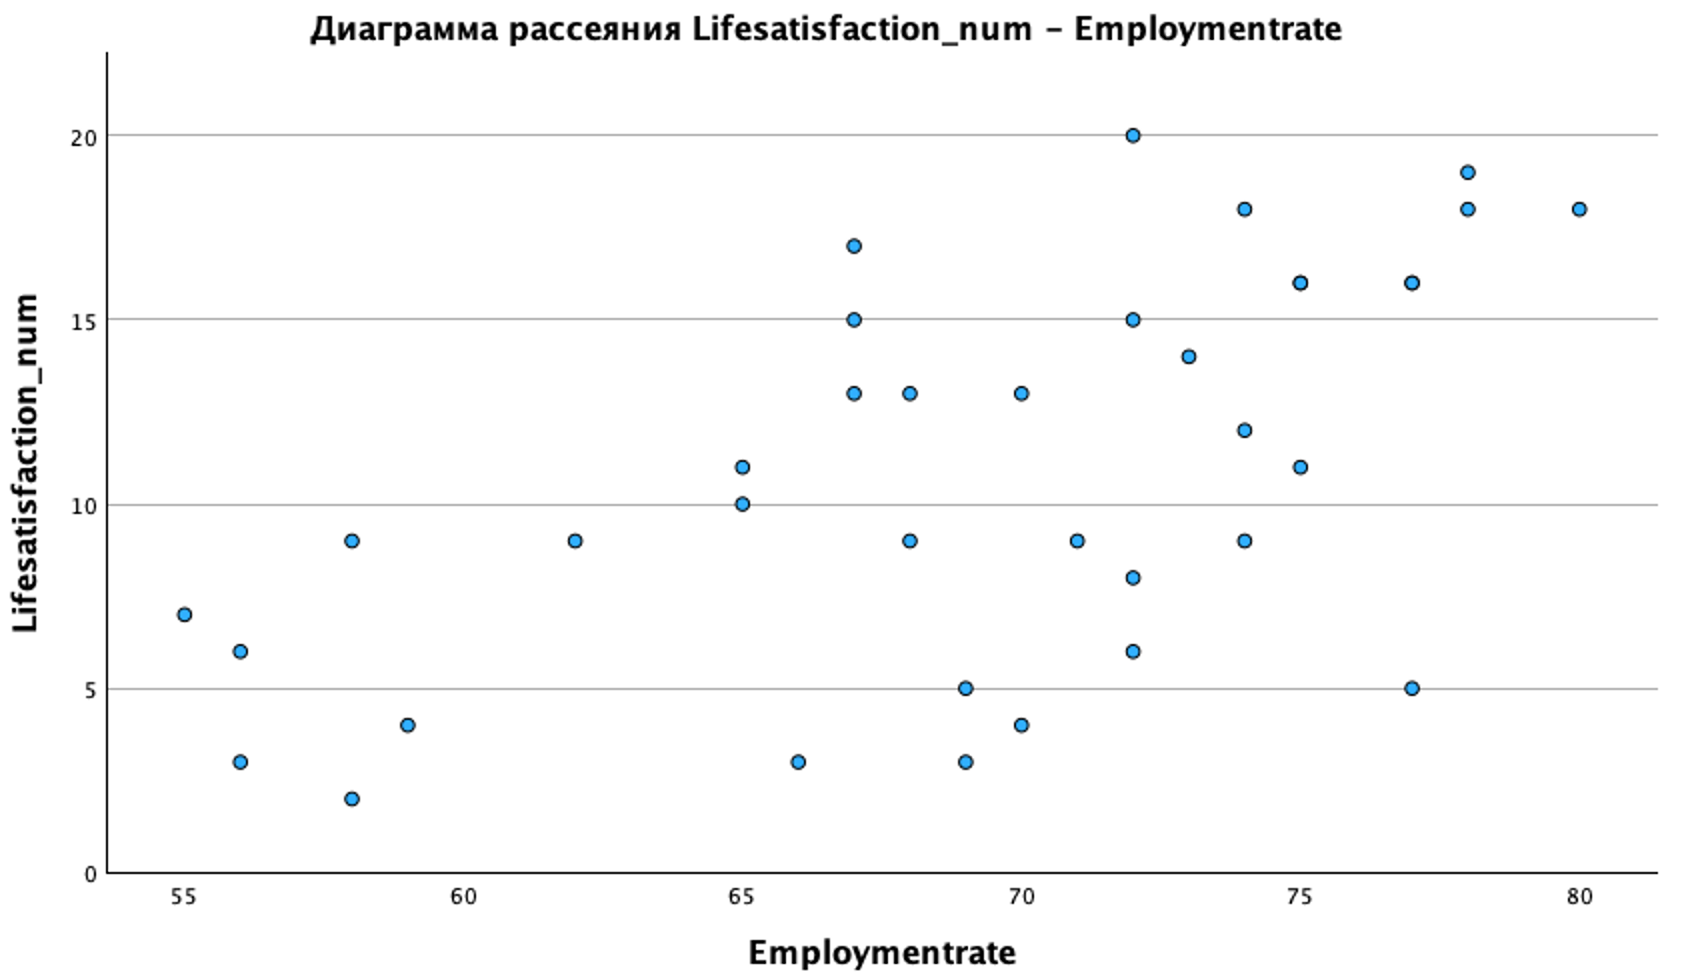

После удаления выброса (страны с аномально низким уровнем занятости — Турции) характер связи между переменными Lifesatisfaction_num и Employment rate изменился. Связь стала более однородной и наглядной, уменьшился разброс значений, а зависимость между переменными стала прослеживаться более чётко. Удаление данного наблюдения позволило устранить искажение общей картины и повысить точность оценки положительной взаимосвязи между уровнем занятости и удовлетворённостью жизнью.

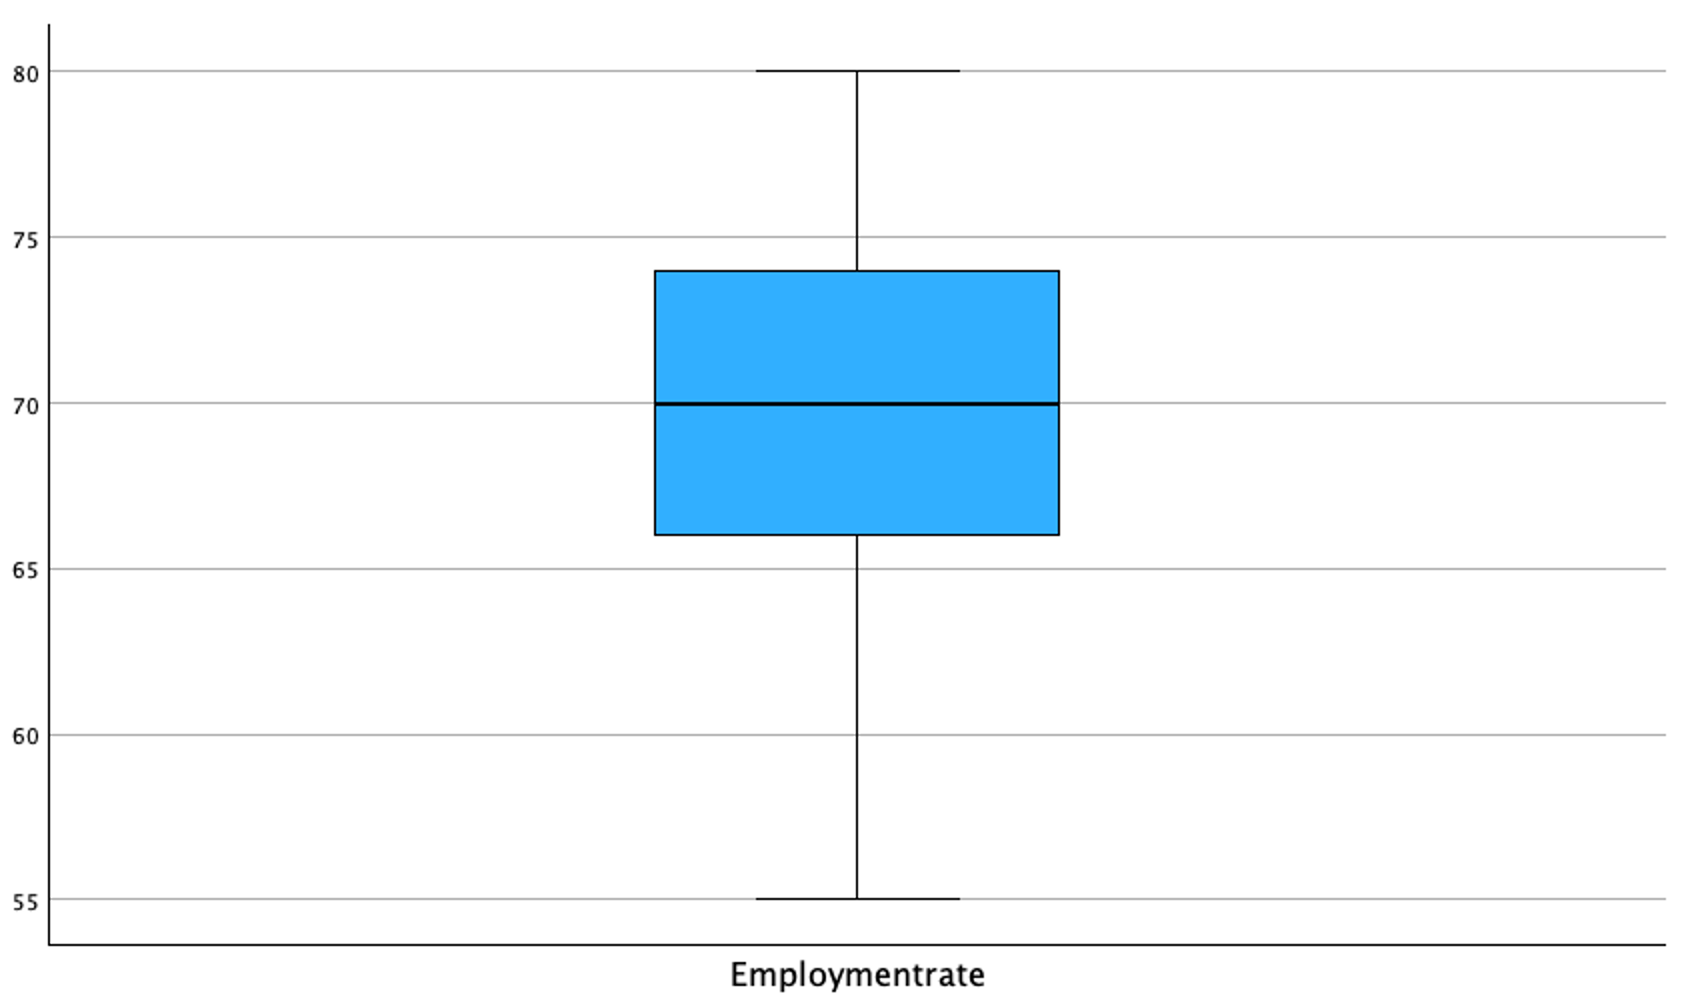

Видно, что после удаления выбросов ящик с усами не выявил больше никаких выбросов, то есть выборка стала однородной

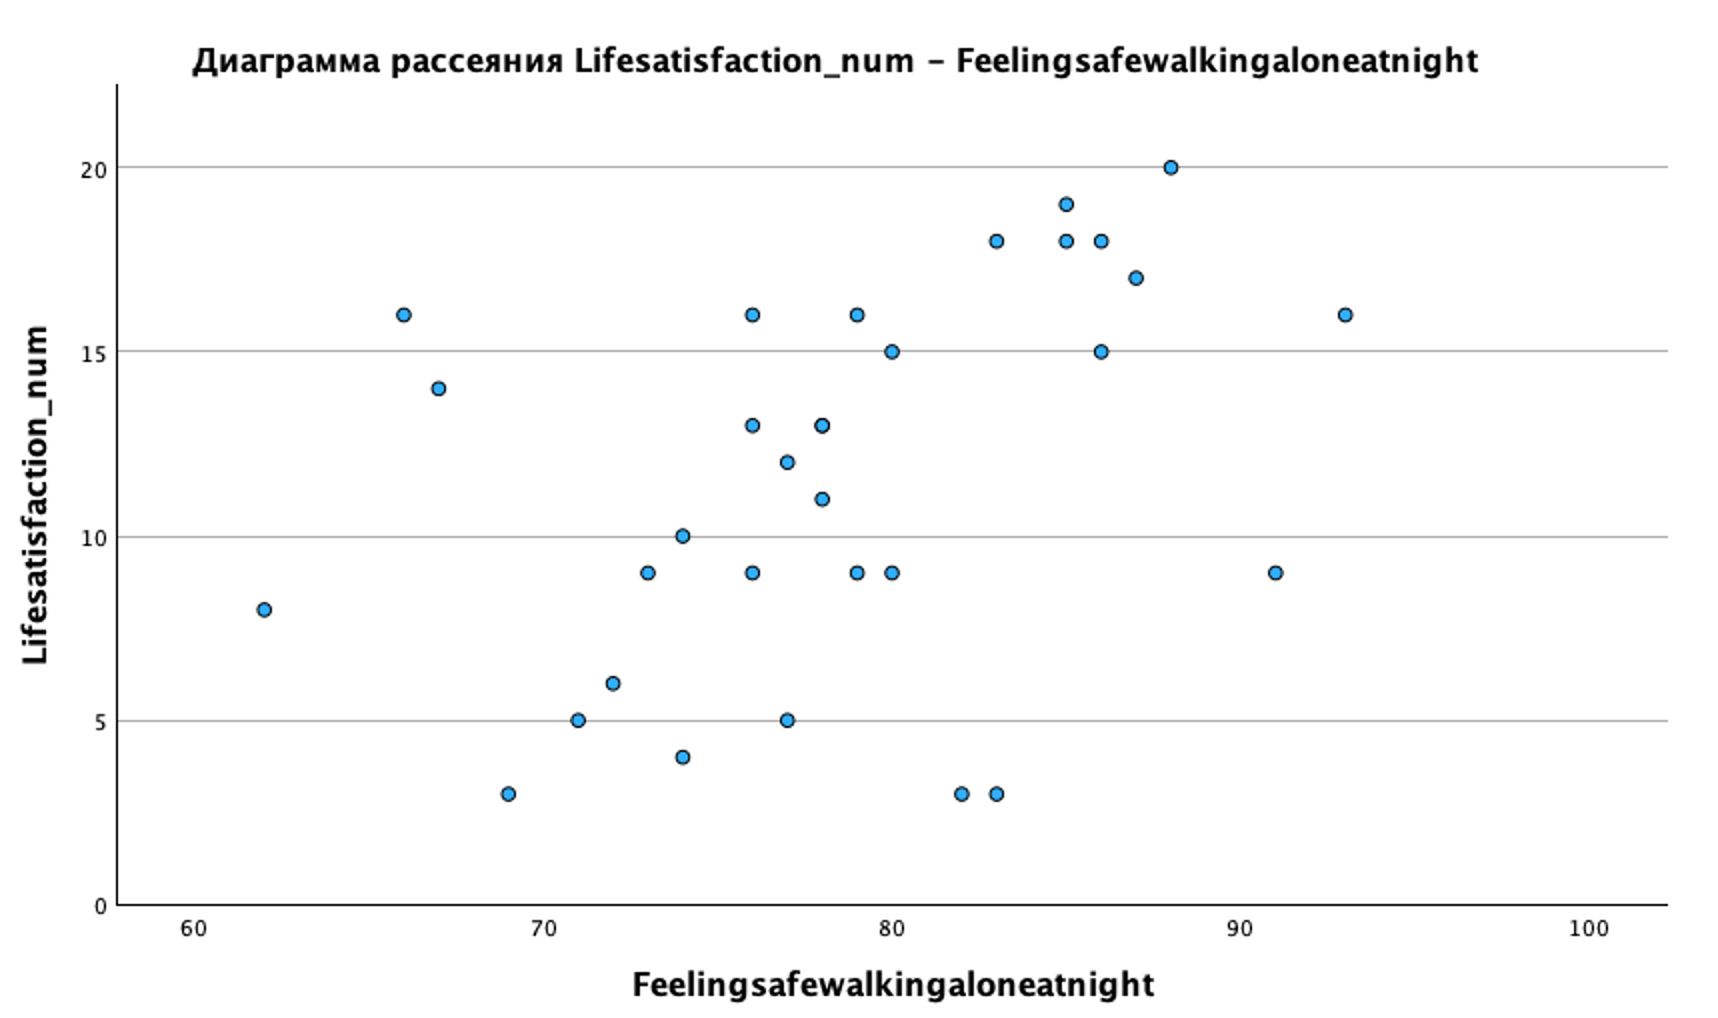

После   удаления выбросов   (Чили, Мексика,   Коста-Рика, Колумбия,   Бельгия и Турция)   связь между переменными   Lifesatisfaction_num и Feeling safe walking alone at night стала   более чёткой   и устойчивой.   Разброс значений   уменьшился, а   точки стали более   компактно располагаться   вдоль положительной   зависимости,   что свидетельствует   об усилении взаимосвязи   между ощущением   безопасности   и удовлетворённостью   жизнью.
Появление данных выбросов можно объяснить различиями в социально-экономических условиях и субъективном восприятии безопасности. В случае Чили, Мексики, Колумбии и Турции отклонения могут быть связаны с более высоким уровнем преступности или ощущением небезопасности, при котором уровень удовлетворённости жизнью не полностью соответствует уровню безопасности. Для Коста-Рики возможна ситуация, при которой относительно высокий уровень удовлетворённости жизнью сочетается с более умеренными оценками безопасности. В случае Бельгии отклонение может быть обусловлено тем, что при высоком уровне развития и удовлетворённости жизнью субъективное ощущение безопасности ниже, чем в среднем по выборке, что может быть связано с особенностями восприятия общественной среды.

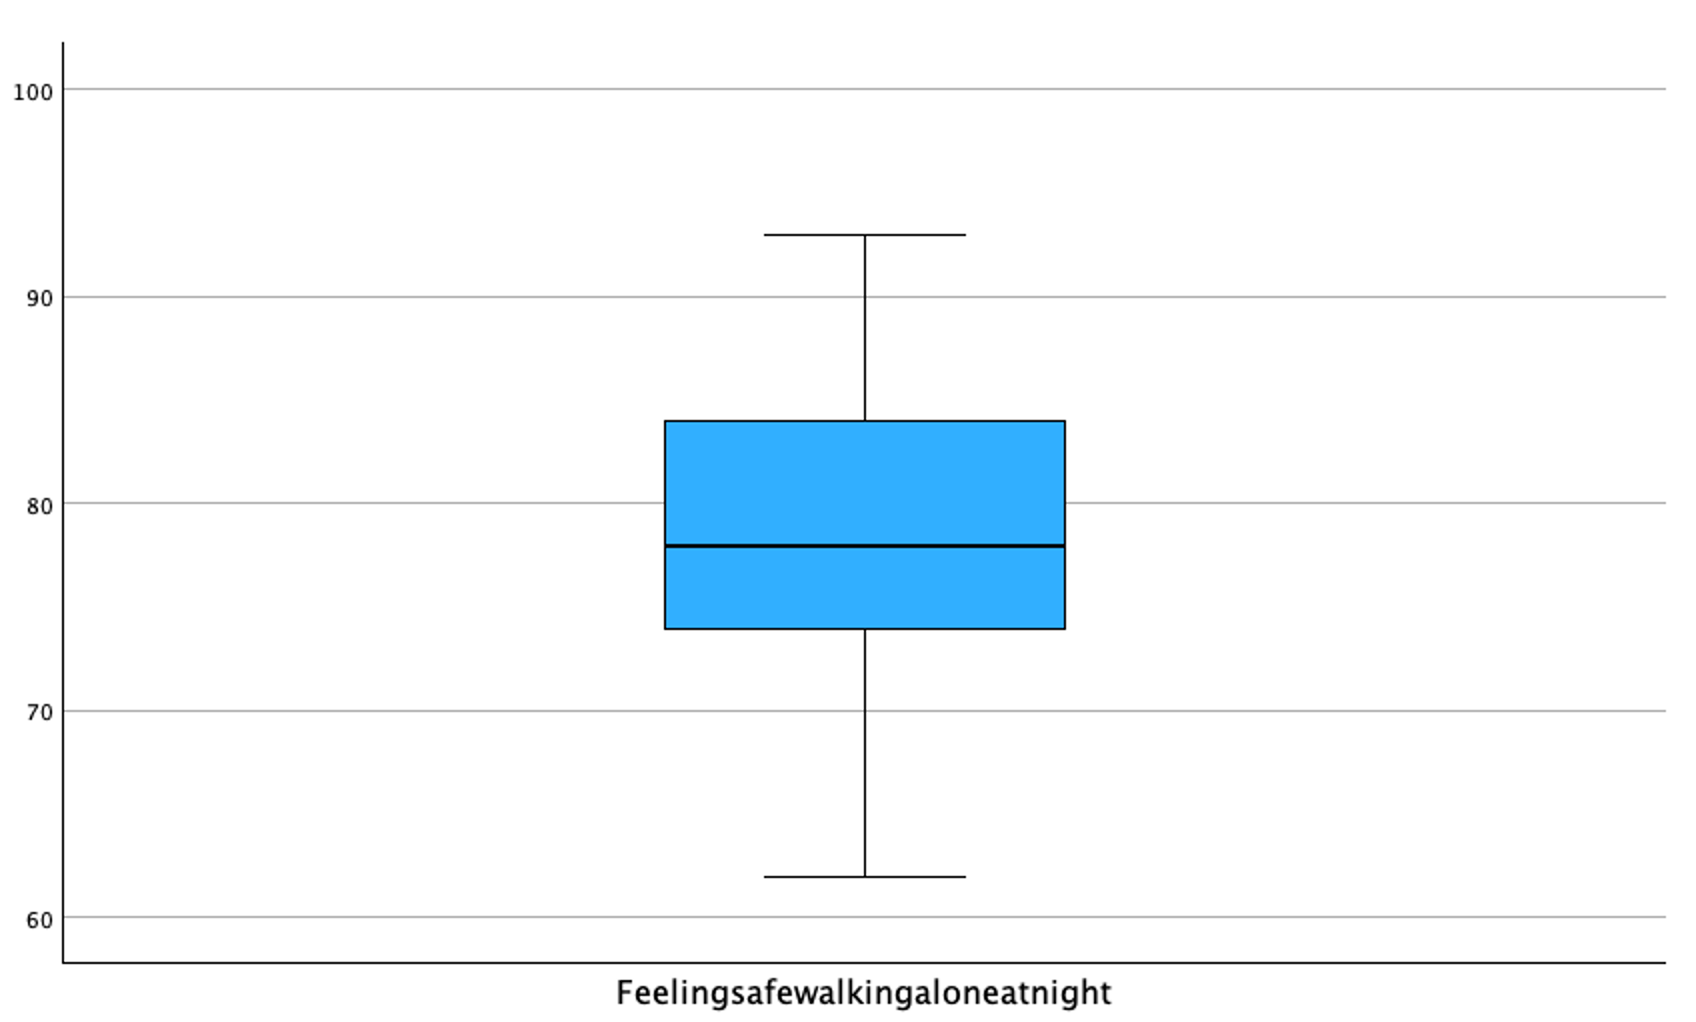

Заметно, что после удаления выбросов ящик с усами не выявил больше никаких выбросов, то есть выборка стала однородной

*МАТРИЦА ПАРНЫХ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ (ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ), СРАВНЕНИЕ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ ДО/ПОСЛЕ*




Коэффициент корреляции до *выбросов*

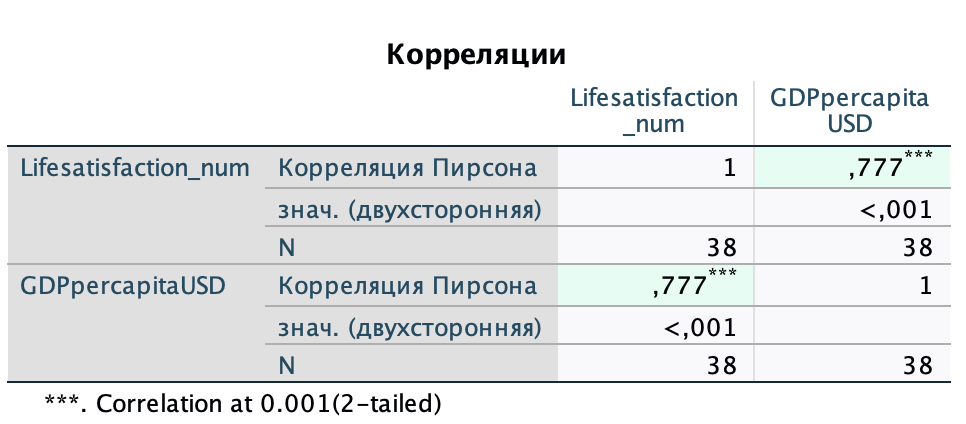

Коэффициент корреляции после выбросов

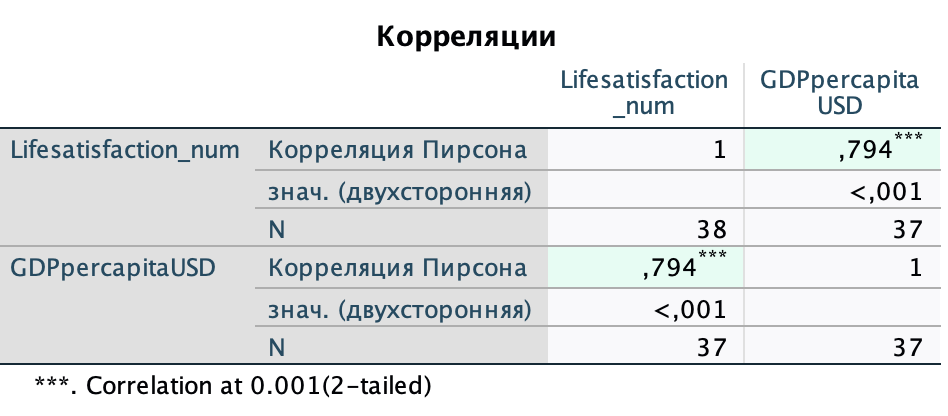

Между Lifesatisfaction_num и GDP per capita коэффициент корреляции увеличился с r = 0,777 до r = 0,794, что свидетельствует об усилении положительной связи после удаления выброса (Люксембурга). Это означает, что ранее экстремально высокое значение ВВП несколько искажало общую зависимость, а после его исключения связь стала более однородной и устойчивой. Связь остаётся сильной и статистически значимой (p < 0,001), что подтверждает важную роль уровня дохода страны в формировании удовлетворённости жизнью.

Коэффициент корреляции до выбросов

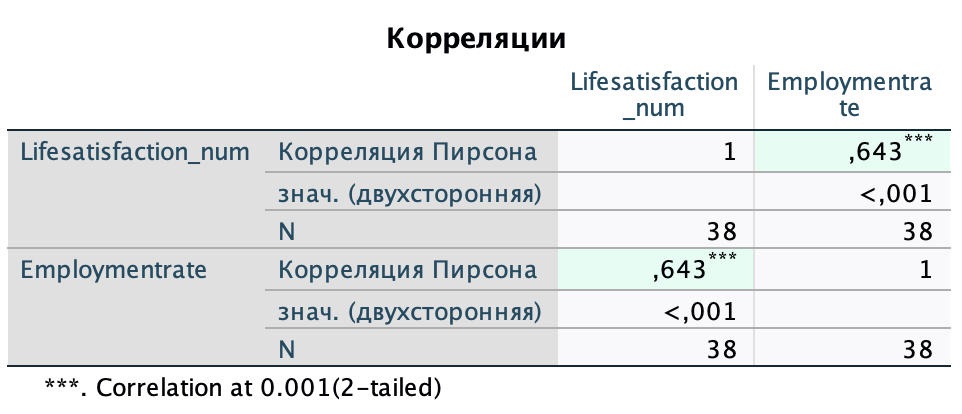

Коэффициент корреляции после выбросов

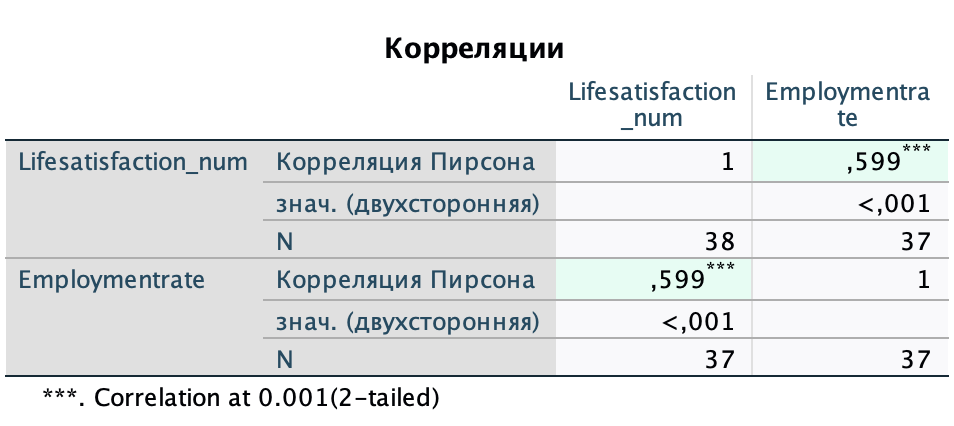

Между   Lifesatisfaction_num и Employment rate коэффициент   корреляции снизился   с r = 0,643 до r = 0,599 после   удаления выброса   (Турции). Это указывает   на то, что ранее   наблюдаемая   связь была частично   усилена наличием   экстремального   значения. После   удаления выброса   связь осталась   положительной   и статистически   значимой (p < 0,001), но   её сила стала   ближе к умеренной,   что говорит о   менее выраженной   зависимости   между занятостью   и удовлетворённостью   жизнью.

Коэффициент корреляции до выбросов

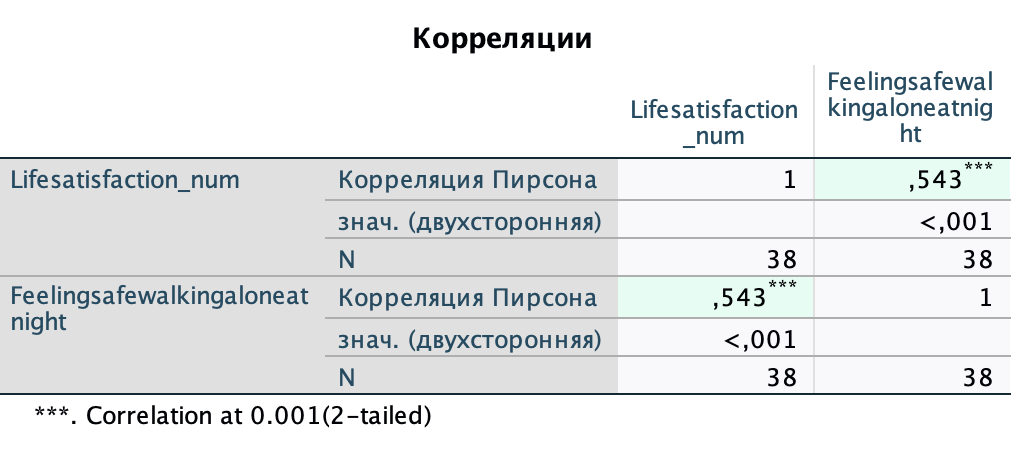

Коэффициент корреляции после выбросов

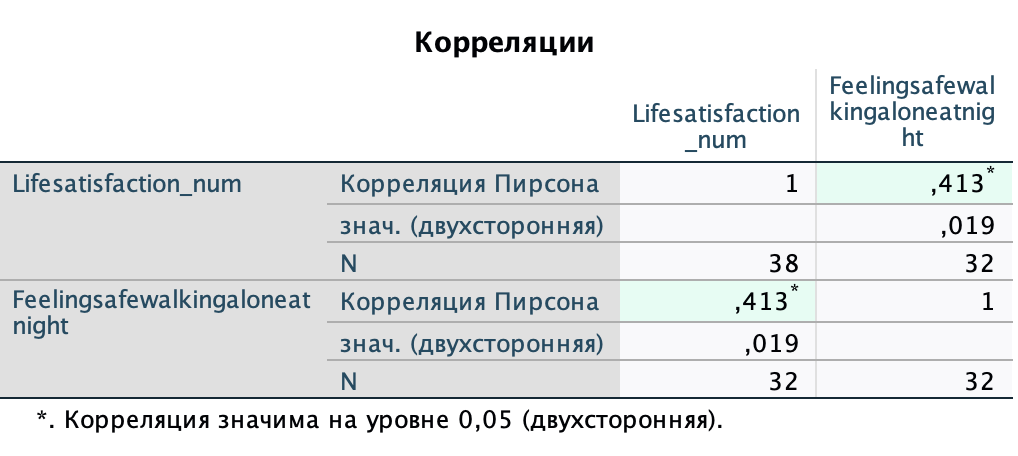

Между Lifesatisfaction_num и Feeling safe walking alone at night коэффициент корреляции уменьшился с r = 0,543 до r = 0,413 после удаления группы выбросов (Чили, Мексика, Коста-Рика, Колумбия, Бельгия и Турция). Это означает, что первоначально связь была завышена за счёт аномальных наблюдений. После их удаления зависимость осталась положительной, но стала заметно слабее и перешла из умеренной в более слабую категорию. Уровень значимости также снизился с p < 0,001 до p = 0,019, хотя связь всё ещё остаётся статистически значимой на уровне 0,05.

*Вывод о связи переменных*

В целом удаление выбросов привело к уточнению структуры взаимосвязей: связь с GDP стала немного сильнее и более стабильной, тогда как связи с Employment rate и ощущением безопасности ослабли, что указывает на то, что ранее они частично искажались аномальными значениями. Наиболее устойчивым и сильным фактором, влияющим на удовлетворённость жизнью, остаётся GDP per capita, в то время как влияние занятости и субъективной безопасности является менее выраженным

*ПОСТРОЕНИЕ И ИНТЕРПРЕТАЦИЯ   МАТРИЦЫ ЧАСТНЫХ КОЭФФИЦИЕНТОВ*

Из дальнейшего анализа может быть исключен показатель Airpollution_num, поскольку между ним и зависимой переменной Lifesatisfaction_num выявлена очень слабая и статистически не значимая связь (r = -0,044; p > 0,05). Следовательно, данный показатель не является информативным для объяснения вариации удовлетворенности жизнью в рамках данной выборки

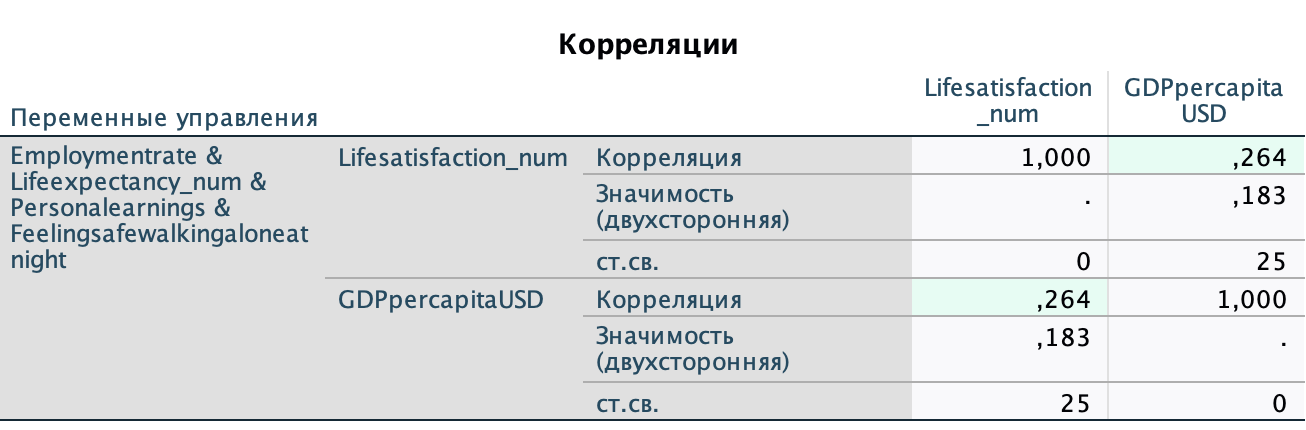

Частная корреляция   позволяет определить   связь между двумя   признаками при   исключении влияния   остальных факторов,   включенных в   модель. В частности, была рассчитана частная корреляция между показателями Lifesatisfaction_num и GDPpercapitaUSDпри контроле переменных Employmentrate, Lifeexpectancy_num, Personalearnings и Feelingsafewalkingaloneatnight. По результатам анализа частный коэффициент корреляции составил:   r     = 0,264        p     = 0,183  .Это означает, что после исключения влияния остальных факторов связь между удовлетворенностью жизнью и ВВП на душу населения становится слабой и статистически незначимой. Следовательно, можно сделать вывод, что исходная высокая связь между данными показателями в значительной степени объяснялась влиянием других социально-экономических факторов.

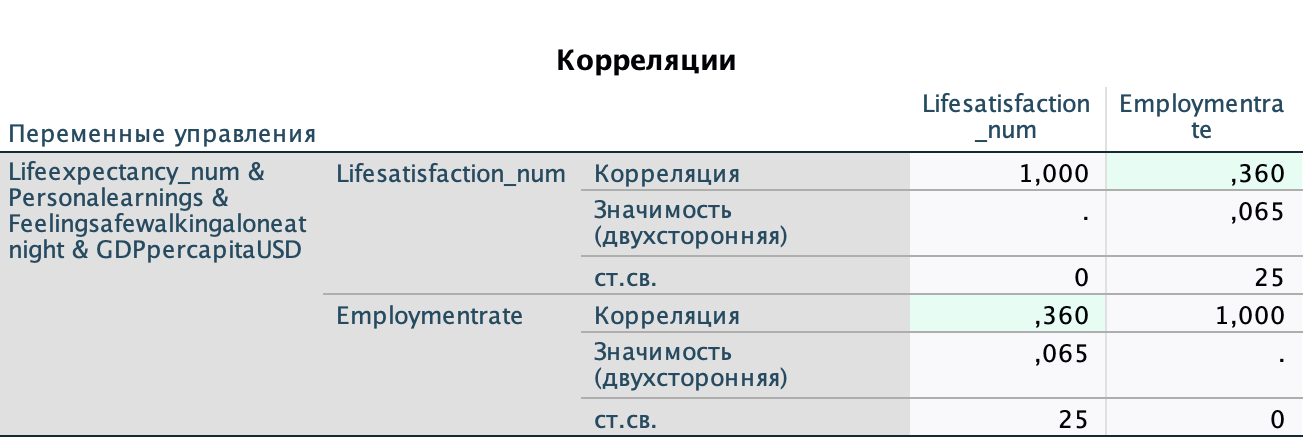

После контроля остальных переменных связь между удовлетворённостью жизнью и уровнем занятости остаётся положительной, но становится умеренно слабой и не достигает стандартного уровня статистической значимости (p > 0,05).Это означает, что Employment rate всё ещё может иметь определённое самостоятельное влияние на удовлетворённость жизнью, однако его вклад уже не является достаточно выраженным после учёта других факторов.

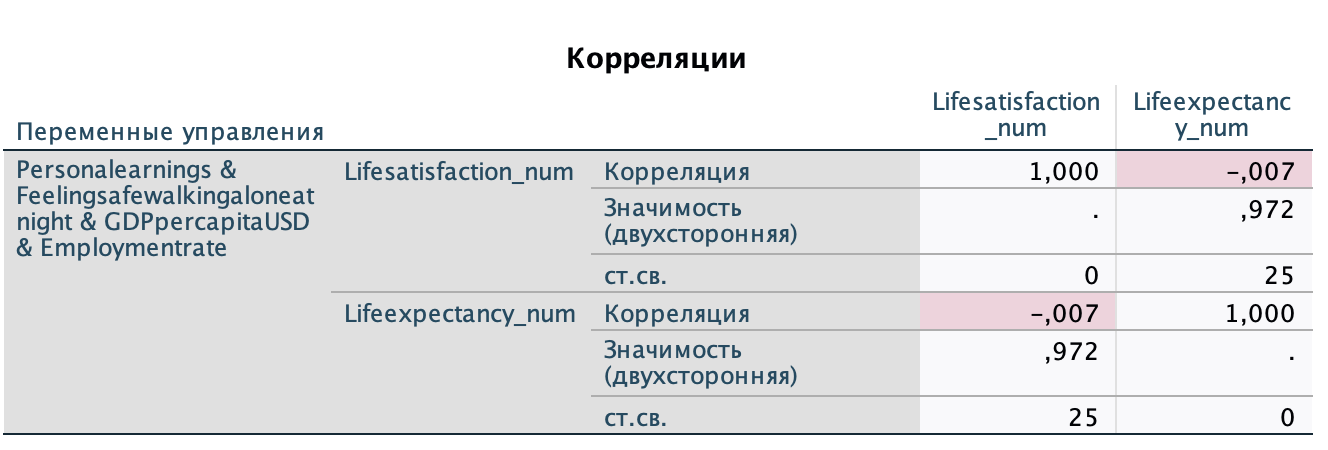

После учета влияния остальных факторов связь между удовлетворённостью жизнью и ожидаемой продолжительностью жизни практически исчезает.Значение коэффициента близко к нулю, а статистическая значимость полностью отсутствует. Это означает, что сама по себе продолжительность жизни не демонстрирует самостоятельной связи с удовлетворённостью жизнью в рамках данной модели.

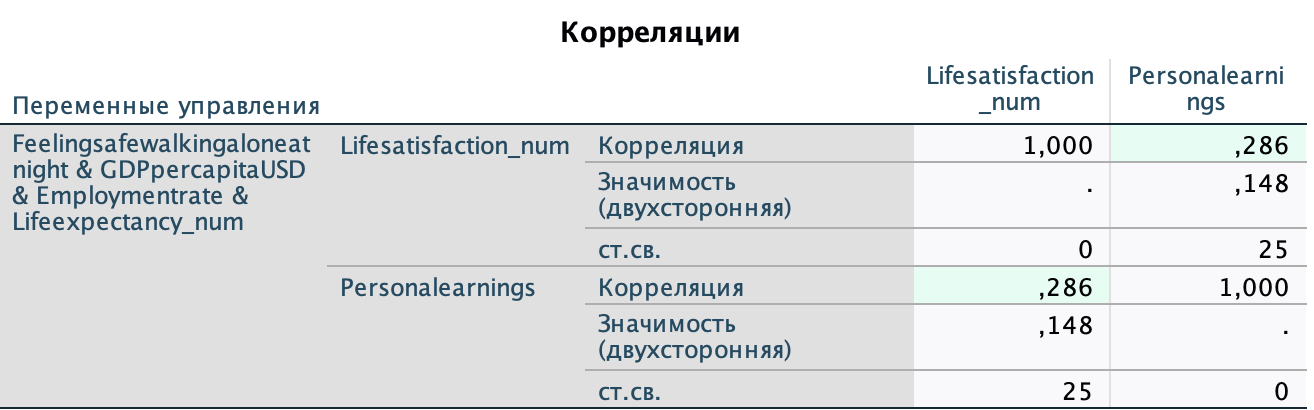

После учета остальных факторов связь между удовлетворённостью жизнью и личными доходами остаётся положительной, но становится слабой и статистически незначимой.Это означает, что показатель Personal earnings в данной модели не объясняет удовлетворённость жизнью самостоятельно, а его первоначально высокая связь, вероятно, обусловлена его тесной взаимосвязью с другими экономическими и социальными переменными

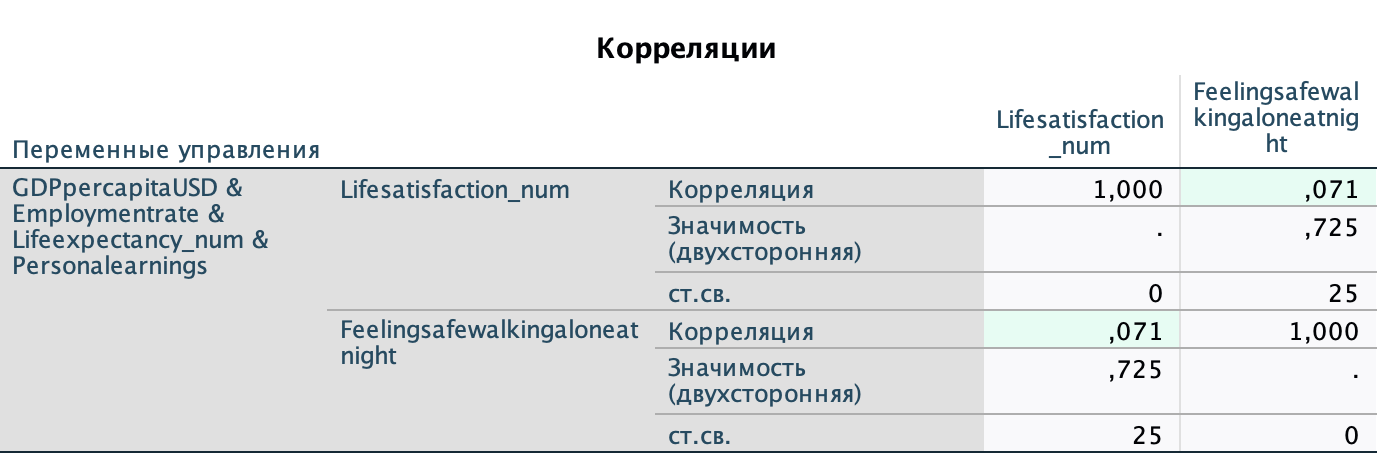

После учета остальных факторов связь между удовлетворённостью жизнью и ощущением безопасности становится очень слабой и статистически незначимой.Это свидетельствует о том, что влияние субъективного ощущения безопасности на удовлетворённость жизнью в рамках данной модели не является самостоятельным, а, вероятно, связано с более общими характеристика
и социально-экономического благополучия.

*СРАВНЕНИЕ МАТРИЦЫ ПАРНЫХ   И ЧАСТНЫХ КОЭФФИЦИЕНТОВ*

Сравнение парных и частных коэффициентов корреляции позволяет глубже понять взаимосвязь между переменными

In [ ]:
import pandas as pd

data = {
    "Переменная": [
        "GDPpercapitaUSD",
        "Employmentrate",
        "Lifeexpectancy_num",
        "Personalearnings",
        "Feelingsafewalkingaloneatnight"
    ],
    "Парный r": [0.777, 0.643, 0.469, 0.782, 0.543],
    "Частный r": [0.264, 0.360, -0.007, 0.286, 0.071],
    "Что произошло": [
        "связь резко ослабла",
        "связь заметно ослабла",
        "связь исчезла",
        "связь резко ослабла",
        "связь почти исчезла"
    ]
}

df = pd.DataFrame(data)
print(df)

                       Переменная  Парный r  Частный r          Что произошло
0                 GDPpercapitaUSD     0.777      0.264    связь резко ослабла
1                  Employmentrate     0.643      0.360  связь заметно ослабла
2              Lifeexpectancy_num     0.469     -0.007          связь исчезла
3                Personalearnings     0.782      0.286    связь резко ослабла
4  Feelingsafewalkingaloneatnight     0.543      0.071    связь почти исчезла


Сравнение парных и частных коэффициентов корреляции показало, что после исключения влияния остальных факторов сила связи между зависимой переменной Lifesatisfaction_num и большинством независимых переменных существенно снижается.Так, для показателя GDPpercapitaUSD парный коэффициент корреляции составлял 0,777, тогда как частный коэффициент снизился до 0,264. Для показателя Employmentrate связь уменьшилась с 0,643 до 0,360. Для Lifeexpectancy_num связь практически исчезла: с 0,469 до -0,007. Для Personalearnings наблюдалось снижение с 0,782 до 0,286, а для Feelingsafewalkingaloneatnight — с 0,543 до 0,071. Это свидетельствует о том, что значительная часть первоначально выявленных парных связей была обусловлена совместным влиянием других факторов, а не самостоятельным воздействием каждой переменной по отдельности. Следовательно, между независимыми переменными наблюдается заметное перекрытие содержания, то есть они частично описывают одни и те же аспекты социально-экономического благополучия. Такое различие между парными и частными коэффициентами может свидетельствовать о наличии взаимосвязи между независимыми признаками и косвенно указывать на возможную мультиколлинеарность.

*РАСЧЕТ МНОЖЕСТВЕННОГО   КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ*

Для оценки совокупной силы связи между зависимой переменной Lifesatisfaction_num и выбранными независимыми переменными был рассчитан множественный коэффициент корреляции. По результатам был найден множественный коэффициент корреляции и
коэффициент детерминации

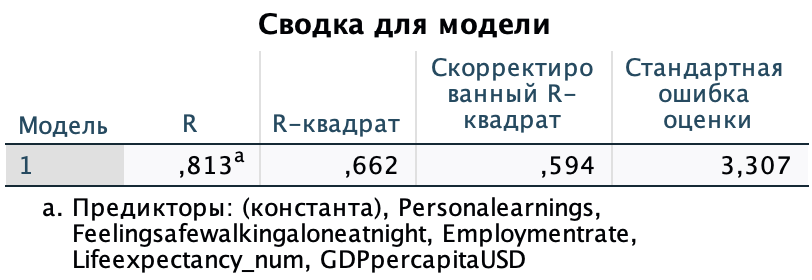

Для оценки общей тесноты связи между зависимой переменной Lifesatisfaction_num и совокупностью отобранных факторов был проведён анализ множественной линейной регрессии в программе SPSS.В качестве зависимой переменной выступал показатель удовлетворённости жизнью (Lifesatisfaction_num). В качестве независимых переменных были включены следующие показатели:

-GDPpercapitaUSD

-Employmentrate

-Lifeexpectancy_num

-Personalearnings

-Feelingsafewalkingaloneatnight

По результатам анализа в таблице Model Summary был получен множественный коэффициент корреляции: R = 0,813
Это свидетельствует о наличии сильной связи между уровнем удовлетворённости жизнью и совокупностью включённых в модель факторов.
Коэффициент детерминации составил: R² = 0,662
Это означает, что 66,2% вариации показателя удовлетворённости жизнью объясняется включёнными в модель независимыми переменными.


*Итоговый вывод*

По итогам корреляционного анализа, выбранные показатели могут быть использованы в дальнейшем регрессионном анализе, однако при интерпретации результатов необходимо учитывать возможную взаимосвязанность отдельных независимых переменных

***РЕГРЕССИОННЫЙ АНАЛИЗ***



Проведём регрессионный анализ, чтобы определить, какие факторы влияют на уровень удовлетворённости жизнью.

В качестве зависимой переменной была выбрана **удовлетворённость жизнью (Life satisfaction)**. Этот показатель отражает, насколько люди в разных странах в целом довольны своей жизнью.

В качестве независимых показателей выбраны:

-ВВП на душу населения (GDP per capita)

-уровень занятости (Employment rate)

-ожидаемая продолжительность жизни (Life expectancy)

-располагаемый доход домохозяйств (Household net adjusted disposable income).

-уровень образования (Educational attainment)

После удаления наблюдений с пропущенными значениями в выборке осталось 32 наблюдения. Таким образом, сформирована итоговая таблица данных размером
33 на 6, которая будет использоваться для построения модели регрессии





In [ ]:
import pandas as pd

df = pd.read_csv("better-life-index-2024.csv")

df.columns = df.columns.str.strip()

print("Названия столбцов после очистки:")
print(df.columns)

y_col = "Life satisfaction"

x_candidates = [
    "GDP per capita (USD)",
    "Household net adjusted disposable income",
    "Employment rate",
    "Educational attainment",
    "Life expectancy"
]

data = df[[y_col] + x_candidates].copy()
data = data.dropna()

print("\nРазмер таблицы после удаления пропусков:")
print(data.shape)

print("\nПервые 5 строк:")
print(data.head())

Названия столбцов после очистки:
Index(['Country', 'GDP per capita (USD)', 'Dwellings without basic facilities',
       'Housing expenditure', 'Rooms per person',
       'Household net adjusted disposable income', 'Household net wealth',
       'Labour market insecurity', 'Employment rate',
       'Long-term unemployment rate', 'Personal earnings',
       'Quality of support network', 'Educational attainment',
       'Student skills', 'Years in education', 'Air pollution',
       'Water quality', 'Stakeholder engagement for developing regulations',
       'Voter turnout', 'Life expectancy', 'Self-reported health',
       'Feeling safe walking alone at night', 'Homicide rate',
       'Employees working very long hours',
       'Time devoted to leisure and personal care', 'Life satisfaction'],
      dtype='object')

Размер таблицы после удаления пропусков:
(32, 6)

Первые 5 строк:
   Life satisfaction  GDP per capita (USD)  \
0                7.1                 66589   
1               

Выведем анализируемую таблицу:

In [ ]:
data_rounded = data.round(2)
display(data_rounded)

,Life satisfaction,GDP per capita (USD),Household net adjusted disposable income,Employment rate,Educational attainment,Life expectancy
0,7.1,66589,37433.0,73,84.0,83.0
1,7.2,59225,37001.0,72,86.0,82.0
2,6.8,55536,34884.0,65,80.0,82.1
3,7.0,54866,34421.0,70,92.0,82.1
6,6.3,18031,16517.0,55,43.0,80.5
7,6.9,29801,26664.0,74,94.0,79.3
8,7.5,68898,33774.0,74,82.0,81.5
9,6.5,31855,23784.0,74,91.0,78.8
10,7.9,55127,33471.0,72,91.0,82.1
11,6.7,47359,34375.0,65,81.0,82.9


Далее была построена модель множественной линейной регрессии для дальнейшей оценки зависимости уровня удовлетворенности жизнью от выбранных нами факторов.

Оценка коэффициентов регрессии была выполнена с помощью метода наименьших квадратов.

Ниже - результаты оценки модели:  
-значения коэффициентов
-их статистическая значимость
-основные характеристики модели

***Таблица коэффициентов***

In [ ]:
import pandas as pd

coef_table = pd.DataFrame({
    "Переменная": model.params.index,
    "Коэффициент": model.params.values,
    "Стандартная ошибка": model.bse.values,
    "t-статистика": model.tvalues.values,
    "p-value": model.pvalues.values
})

# перевод названий переменных
name_map = {
    "const": "Константа (свободный член ур-ия регрессии)",
    "GDP per capita (USD)": "ВВП на душу населения",
    "Household net adjusted disposable income": "Располагаемый доход домохозяйств",
    "Employment rate": "Уровень занятости",
    "Educational attainment": "Уровень образования",
    "Life expectancy": "Ожидаемая продолжительность жизни"
}

coef_table["Переменная"] = coef_table["Переменная"].map(name_map)

coef_table = coef_table.round(4)

coef_table

,Переменная,Коэффициент,Стандартная ошибка,t-статистика,p-value
0,Константа (свободный член ур-ия регрессии),1.5236,2.5075,0.6076,0.5487
1,ВВП на душу населения,0.0000,0.0000,1.3516,0.1881
2,Располагаемый доход домохозяйств,0.0000,0.0000,1.8961,0.0691
3,Уровень занятости,0.0355,0.0132,2.6854,0.0124
4,Уровень образования,-0.0038,0.0059,-0.6502,0.5213
5,Ожидаемая продолжительность жизни,0.0253,0.0297,0.8527,0.4016


***Основные характеристики модели***

In [ ]:
import pandas as pd

model_info_df = pd.DataFrame({
    "Показатель": [
        "Коэффициент детерминации (R квадрат)",
        "Скорректированный R квадрат",
        "F-статистика",
        "p-value"
    ],
    "Значение": [
        round(model.rsquared, 4),
        round(model.rsquared_adj, 4),
        round(model.fvalue, 4),
        round(model.f_pvalue, 6)
    ]
})

model_info_df

,Показатель,Значение
0,Коэффициент детерминации (R квадрат),0.711100
1,Скорректированный R квадрат,0.655500
2,F-статистика,12.798900
3,p-value,0.000002


На основании полученных результатов регрессионной модели были получены оценки для коэффициентов регрессии.


Проверка значимости модели в целом проводилась с помощью F-критерия.

***-Значение F-статистики =12.7989***,

***-p-value равно 0.000002.***

Поскольку p-value *меньше 0.05*, нулевая гипотеза отвергается.

Следовательно, уравнение регрессии в целом является статистически значимым, и выбранные факторы совместно оказывают влияние на переменную Life satisfaction.

***-Коэффициент детерминации R квадрат = 0.7111***

***-Скорректированный коэффициент детерминации — 0.6555.***

Это означает, что модель объясняет около 71.1% вариации уровня удовлетворенности жизнью, что свидетельствует о достаточно хорошем качестве модели.

Анализ значимости отдельных коэффициентов показал:

***-Переменная «уровень занятости» является статистически значимой*** *(p-value = 0.0124 < 0.05*). Это означает, что данный фактор оказывает значимое влияние на зависимую переменную.

***-Переменная «располагаемый доход домохозяйств» имеет *p-value = 0.0691*, что немного превышает уровень значимости 0.05, поэтому ее можно считать слабо значимой***.

***-Остальные переменные (ВВП на душу населения, уровень образования, ожидаемая продолжительность жизни) имеют p-value больше 0.05 и не являются статистически значимыми в рамках данной модели.***


Таким образом, построенная модель является статистически значимой и обладает хорошей объясняющей способностью. Однако большинство переменных оказались незначимыми, что указывает на необходимость дальнейшего отбора факторов с использованием пошаговых методов.

На следующем этапе проведем отбор переменных с помощью метода включения и метода исключения.

Цель - выбор наиболее значимых факторов.

Метод пошагового включения начинается с пустой модели и последовательно добавляет переменные, которые оказываются статистически значимыми. Метод пошагового исключения, наоборот, начинается с полной модели и последовательно удаляет статистически незначимые переменные

In [ ]:
import pandas as pd
import statsmodels.api as sm

df2 = df.copy()
df2.columns = df2.columns.str.strip()

cols = [
    "Life satisfaction",
    "GDP per capita (USD)",
    "Household net adjusted disposable income",
    "Employment rate",
    "Educational attainment",
    "Life expectancy"
]

work = df2[cols].copy()

for col in cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

work = work.dropna().reset_index(drop=True)

y = work["Life satisfaction"].astype(float)
X = work.drop(columns=["Life satisfaction"]).astype(float)

def forward_selection(X, y, alpha=0.05):
    remaining = list(X.columns)
    selected = []

    while len(remaining) > 0:
        results = []

        for var in remaining:
            vars_now = selected + [var]
            X_test = sm.add_constant(X[vars_now], has_constant="add").astype(float)
            model = sm.OLS(y.astype(float), X_test).fit()
            pval = model.pvalues[var]
            results.append((var, pval))

        results = sorted(results, key=lambda x: x[1])
        best_var, best_pval = results[0]

        if best_pval < alpha:
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break

    return selected

def backward_elimination(X, y, alpha=0.05):
    selected = list(X.columns)

    while len(selected) > 0:
        X_test = sm.add_constant(X[selected], has_constant="add").astype(float)
        model = sm.OLS(y.astype(float), X_test).fit()
        pvalues = model.pvalues.drop("const")

        if len(pvalues) == 0:
            break

        worst_pval = pvalues.max()
        worst_var = pvalues.idxmax()

        if worst_pval > alpha:
            selected.remove(worst_var)
        else:
            break

    return selected

forward_vars = forward_selection(X, y)
backward_vars = backward_elimination(X, y)

print("Размер данных:", work.shape)
print("Метод включения:", forward_vars)
print("Метод исключения:", backward_vars)

Размер данных: (32, 6)
Метод включения: ['Household net adjusted disposable income', 'Employment rate']
Метод исключения: ['Household net adjusted disposable income', 'Employment rate']


На основании выше полученных результатов видим, что с помощью каждого из методов были получены одинаковые результаты, а именно, что в итоговую модель вошли переменные:

***-Распологаемый доход домохозяйств***

***-Уровень занятости***

Иными словами, именно эти факторы вносят наибольший вклад в объяснение зависимой переменной "Life satisfaction" (удовлетворенность жизнью)

Более того, совпадение результатов говорит о том,что выбор модели является достаточно устойчивым.

Построим финальную регрессионную модель, включающую только 2 переменные.


In [ ]:
import statsmodels.api as sm
import pandas as pd

final_X = work[[
    "Household net adjusted disposable income",
    "Employment rate"
]].copy()

final_y = work["Life satisfaction"].copy()

final_X = sm.add_constant(final_X)

final_model = sm.OLS(final_y, final_X).fit()

coef_table_final = pd.DataFrame({
    "Переменная": [
        "Константа",
        "Располагаемый доход домохозяйств",
        "Уровень занятости"
    ],
    "Коэффициент": final_model.params.values,
    "Стандартная ошибка": final_model.bse.values,
    "t-статистика": final_model.tvalues.values,
    "p-value": final_model.pvalues.values
}).round(4)

model_info_final = pd.DataFrame({
    "Показатель": [
        "Коэффициент детерминации (R²)",
        "Скорректированный R²",
        "F-статистика",
        "p-value (F-критерия)"
    ],
    "Значение": [
        round(final_model.rsquared, 4),
        round(final_model.rsquared_adj, 4),
        round(final_model.fvalue, 4),
        round(final_model.f_pvalue, 6)
    ]
})

coef_table_final
model_info_final

,Показатель,Значение
0,Коэффициент детерминации (R²),0.6649
1,Скорректированный R²,0.6418
2,F-статистика,28.7676
3,p-value (F-критерия),0.0000


Итак, после пошагового отбора была построена итоговая модель множественной линейной регрессии, в которую вошли 2 переменные:

***-Распологаемый доход***
***-Уровень занятости***


Проверка значимости уравнения проводилась с помощью F-критерия:

***-Значение F-статистики = 28.7676***
***-p-value = 0.00000....***

Поскольку p-value заметно меньше 0.05, то нулевая гипотеза отвергается. Следовательно, модель статистически значима.

***-Коэффициент детерминации R квадрат = 0.6649***
***-Скорректированный коэффициент R квадрат =0.6418***
Это означает, что построенная нами модель объясняет примерно 66.5% вариации переменной Life satisfaction, то есть модель относительно точная.

По сравнению с изначальной моделью, новая модель достаточно компактная, но в то же время сохраняе качество обхяснения зависимой переменной. Поэтому будет целесообразно использовать вторую модель.


Далее была проведена проверка значимости отдельных коэффициентов регрессии с помощью t-статистики.
По результатам анализа обе переменные, вошедшие в итоговую модель, оказались статистически значимыми. Для переменной «располагаемый доход домохозяйств» p-value равно 0.0000, а для переменной «уровень занятости» p-value равно 0.0156. Поскольку в обоих случаях p-value меньше 0.05, можно сделать вывод о статистической значимости этих факторов.
Коэффициенты при обеих переменных положительны, что означает, что увеличение располагаемого дохода и уровня занятости приводит к росту уровня удовлетворенности жизнью при прочих равных условиях.
Таким образом, в результате регрессионного анализа была построена статистически значимая модель, включающая наиболее важные факторы. Модель обладает хорошей объясняющей способностью и может быть использована для анализа зависимости переменной Life satisfaction.



In [ ]:
print(coef_table_final.to_string(index=False))

                      Переменная  Коэффициент  Стандартная ошибка  t-статистика  p-value
                       Константа       3.4640              0.6907        5.0151   0.0000
Располагаемый доход домохозяйств       0.0000              0.0000        5.1660   0.0000
               Уровень занятости       0.0283              0.0110        2.5694   0.0156


***Кластерный анализ***

В этом разделе проводится кластерный анализ стран по показателям качества жизни. Цель — разделить страны на группы, внутри которых они похожи друг на друга.
Для анализа используются количественные показатели. Так как они измеряются в разных единицах, данные предварительно стандартизируются.
Сначала будет выполнена иерархическая кластеризация и построены дендрограммы разными методами. Это нужно, чтобы понять, на сколько кластеров лучше разделить страны.
В качестве меры расстояния используется евклидово расстояние, так как оно подходит для количественных данных и является наиболее распространённым.
Далее на основе дендрограмм будет выбрано число кластеров и проведена кластеризация методом k-средних.

***Пункт а*** - посмотрим, как можно разбить наши страны на "кластеры" . Для этого рассмотрим 5 вариантов:


1.   Метод ближнего соседа
2.   Метод дальнего соседа

1.   Центр тяжести
2.   Средняя связь











In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster

df = pd.read_csv('better-life-index-2024.csv')
df.columns = df.columns.str.strip()

data = df[['Country',
           'GDP per capita (USD)',
           'Employment rate',
           'Life expectancy',
           'Life satisfaction']].dropna()

X = data[['GDP per capita (USD)',
          'Employment rate',
          'Life expectancy',
          'Life satisfaction']]

X = (X - X.mean()) / X.std()

# методы
Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')
Z_average = linkage(X, method='average')
Z_centroid = linkage(X, method='centroid')
Z_ward = linkage(X, method='ward')

# делим на 3 кластера
c_single = fcluster(Z_single, 3, criterion='maxclust')
c_complete = fcluster(Z_complete, 3, criterion='maxclust')
c_average = fcluster(Z_average, 3, criterion='maxclust')
c_centroid = fcluster(Z_centroid, 3, criterion='maxclust')
c_ward = fcluster(Z_ward, 3, criterion='maxclust')

print('single - ближнего соседа:')
print(c_single)
print()

print('complete - дальнего соседа:')
print(c_complete)
print()

print('average - средней связи:')
print(c_average)
print()

print('centroid - центра тяжести:')
print(c_centroid)
print()

print('ward:')
print(c_ward)
print()

single - ближнего соседа:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1
 2]

complete - дальнего соседа:
[1 1 2 1 2 3 2 1 1 1 1 2 1 2 3 1 1 1 2 2 2 3 3 1 3 1 1 1 3 2 3 1 2 1 1 3 1
 1]

average - средней связи:
[2 2 3 2 3 1 3 3 2 3 2 3 2 3 3 2 2 2 3 3 3 3 3 2 1 2 2 2 3 3 3 3 3 2 2 1 3
 2]

centroid - центра тяжести:
[2 2 3 2 3 1 3 3 2 3 2 3 2 3 3 2 2 3 3 3 3 3 3 2 1 2 2 2 3 3 3 3 3 2 2 1 2
 2]

ward:
[1 1 3 1 2 2 2 3 1 3 1 3 1 2 3 1 1 1 3 3 3 3 3 1 2 1 1 1 3 3 3 3 3 1 1 2 3
 1]



В результате выполнения кода каждой стране был присвоен номер: 1, 2 или 3, что соответствует номеру кластера.
Таким образом, все страны были разбиты на 3 различные группы. (Например, если у страны номер 1 - то страна относится к 1-му кластеру)

Выше проведена кластеризация несколькими методами:
*single, complete, average, centroid и ward.* Эти методы отличаются тем, как именно они объединяют страны в кластеры.

-*Метод single (ближнего соседа)* объединяет кластеры по самым близким объектам. То есть он смотрит только на минимальное расстояние между странами. Из-за этого кластеры могут “вытягиваться” и объединяться слишком рано. В результате в нашем случае почти все страны попали в один кластер(а если точнее, то большей части стран был присвоен кластер номер 1), поэтому этот метод оказался неудачным.

-*Метод complete (дальнего соседа)* работает наоборот: он смотрит на самые дальние объекты между кластерами. Из-за этого кластеры получаются более “сжатыми” и аккуратными. В нашем случае он дал более разумное разбиение(номера 1, 2 и 3 распределены по странам более равномерно)

-*Метод average (средней связи)* берёт среднее расстояние между всеми объектами двух кластеров. Это более “сбалансированный” подход, и он тоже дал достаточно сбалансированное разбиение (как и в случае с методом complete, номера 1,2 и 3 распределены более равномерно(

-Метод centroid (центра тяжести) объединяет кластеры по расстоянию между их центрами (средними значениями). Это тоже даёт достаточно логичное разбиение.
Метод ward объединяет кластеры так, чтобы внутри них было как можно меньше различий. Он старается сделать кластеры максимально однородными. Поэтому его часто используют на практике. В нашем случае он тоже дал хороший результат, как и в двух предыдущих методах.


Итак, по результатам видно, что:
метод single почти не разделил страны: большинство стран получили номер 1, а именно оказались в одном кластере.
Три оставшихся метода - методы complete, average, centroid и ward распределили страны на три кластера более равномерно, чем первый метод.

Это означает, что в данных действительно есть несколько групп стран с похожими параметрами.

Делаем вывод, что разумно делить страны примерно на 3 кластера, так как большинство методов дают именно такое разбиение. В пункте б мы проверим и подтвердим правильность данного предположения, что оптимальное количество кластеров - это 3.

***Пункт б***- сделаем вывод о наиболее преподчтительном количестве кластеров.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    print('k =', k, 'score =', round(score, 3))

k = 2 score = 0.376
k = 3 score = 0.385
k = 4 score = 0.309
k = 5 score = 0.341


Чтобы определить оптимальное число кластеров, был использован ***"коэффициент силуэта"***.

Этот показатель показывает, насколько объекты внутри кластера похожи друг на друга и насколько они отличаются от объектов из других кластеров.

Были рассмотрены варианты разбиения на 2, 3, 4 и 5 кластеров. Для каждого варианта рассчитано значение коэффициента силуэта.

Полученные значния таковы:

2 кластера: 0.376

3 кластера: 0.385

4 кластера: 0.309

5 кластеров: 0.341


Итак, видно, что наибольшее значение коэффициента силуэта наблюдается при разбиении ***на 3 кластера.***

Нарисуем дендрограмму

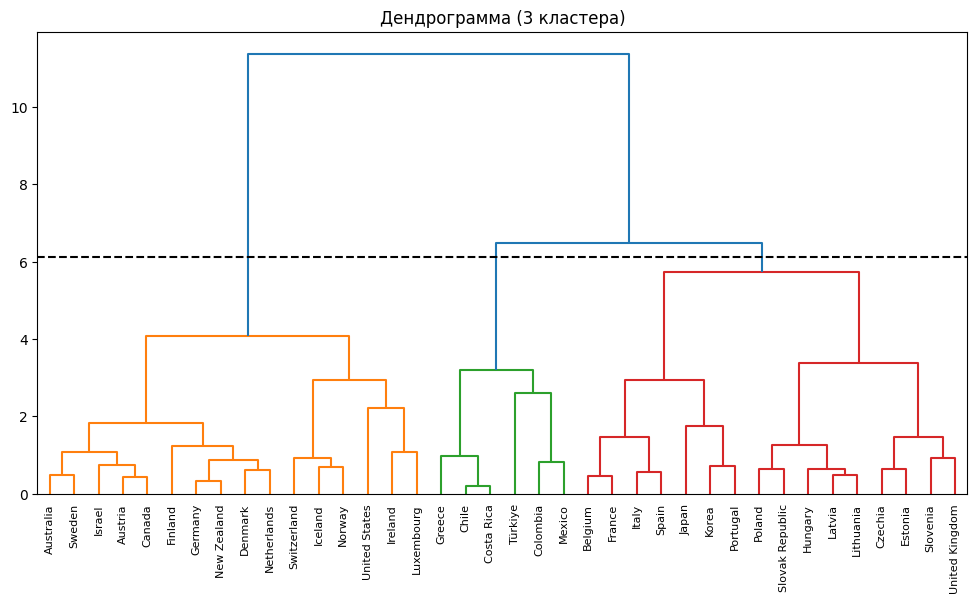

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv('better-life-index-2024.csv')
df.columns = df.columns.str.strip()

data = df[['Country',
           'GDP per capita (USD)',
           'Employment rate',
           'Life expectancy',
           'Life satisfaction']].dropna()

X = data[['GDP per capita (USD)',
          'Employment rate',
          'Life expectancy',
          'Life satisfaction']]

X = (X - X.mean()) / X.std()

Z = linkage(X, method='ward')

n = len(X)
k = 3

h1 = Z[n - k - 1, 2]
h2 = Z[n - k, 2]
t = (h1 + h2) / 2

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=data['Country'].values, color_threshold=t)
plt.axhline(y=t, color='black', linestyle='--')
plt.title('Дендрограмма (3 кластера)')
plt.xticks(rotation=90)
plt.show()

По составленной выше дендрограмме видно, как страны объединяются в группы по степени схожести.

По оси X расположены страны.

По оси Y — расстояние между кластерами (насколько сильно отличаются группы).

Сначала объединяются наиболее похожие страны, затем группы объединяются между собой.
Горизонтальная линия показывает уровень разбиения. Ниже неё видно 3 кластера (разные цвета):

левый (оранжевый) — страны с более высокими показателями,

средний (зелёный) — страны со средними значениями,

правый (красный) — страны с более низкими значениями.


***Пункт с и d*** - метод к-средних

После определения числа кластеров проводится кластеризация методом к-средних.
Ранее было определено оптимальное количество кластеров, а именно k = 3.
Метод к-средних разбивает страны на группы так, чтобы внутри каждого кластера страны были максимально похожи друг на друга, а между кластерами — различались.

В качестве признаков используются показатели качества жизни. Перед кластеризацией данные стандартизовались.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

data['cluster'] = labels

print(data[['Country', 'cluster']].sort_values('cluster'))

            Country  cluster
2           Belgium        0
4             Chile        0
6        Costa Rica        0
11           France        0
13           Greece        0
20            Korea        0
18            Italy        0
19            Japan        0
31         Slovenia        0
29         Portugal        0
35          Türkiye        0
32            Spain        0
15          Iceland        1
1           Austria        1
10          Finland        1
12          Germany        1
27           Norway        1
26      New Zealand        1
25      Netherlands        1
17           Israel        1
8           Denmark        1
23       Luxembourg        1
16          Ireland        1
0         Australia        1
34      Switzerland        1
33           Sweden        1
37    United States        1
36   United Kingdom        1
3            Canada        1
9           Estonia        2
14          Hungary        2
7           Czechia        2
30  Slovak Republic        2
28           P


Итак,как ранее было неоднократно упомянуто, в результате кластеризации страны были разделены на 3 группы.

**Кластер 1** включает страны с наиболее высокими показателями качества жизни:
Australia, Austria, Canada, Denmark, Finland, Germany, Iceland, Ireland, Israel, Luxembourg, Netherlands, New Zealand, Norway, Sweden, Switzerland, United Kingdom, United States.

Это в основном развитые страны с высоким уровнем дохода, занятости и продолжительности жизни.

**Кластер 0** включает страны со средними значениями показателей:
Belgium, Chile, Costa Rica, France, Greece, Italy, Japan, Korea, Portugal, Slovenia, Spain, Türkiye.

Эти страны имеют относительно хорошие показатели, но в среднем уступают первой группе по параметрам качетсва жизни.

**Кластер 2** включает страны с более низкими значениями показателей:
Colombia, Czechia, Estonia, Hungary, Latvia, Lithuania, Mexico, Poland, Slovak Republic.

Для этих стран характерен более низкий относительный уровень дохода и других показателей, которые изммеряют качество жизни, по сравнению с другими кластерами.


Таким образом, кластеризация методом k-средних позволила выделить три группы стран:
страны с высоким, средним и более низким уровнем качества жизни.


***Пункт е*** - график средних и описание кластеров

Для более детального анализа каждого из кластеров рассчитаны средние значения показателей внутри каждого кластера.
Это позволяет понять,чем именно отличаются группы стран друг от друга и какие характеристики для них типичны, чтобы дать содержательное описание.

In [ ]:
cluster_means = data.groupby('cluster')[['GDP per capita (USD)',
                                         'Employment rate',
                                         'Life expectancy',
                                         'Life satisfaction']].mean()

print(cluster_means)

         GDP per capita (USD)  Employment rate  Life expectancy  \
cluster                                                           
0                31516.333333        62.333333        82.083333   
1                73058.352941        73.235294        82.258824   
2                23233.444444        68.444444        77.111111   

         Life satisfaction  
cluster                     
0                 6.158333  
1                 7.288235  
2                 6.255556  


Итак, значения средних для каждого кластера:

**Кластер 1** имеет наиболее высокие значения:

ВВП на душу населения —  **73058 долларов**,

уровень занятости — **73.2%**,

продолжительность жизни — **82.3 года**

удовлетворённость жизнью — **7.29**.

=> Средние значения подтверждают правильность ранее выдвинутой гипотезы - у первого кластера выскоие относительные показатели благополучия.

**Кластер 0** занимает промежуточное положение:

ВВП — около **31516 долларов**,

занятость — **62.3%**,

продолжительность жизни — **82.1 года**,

удовлетворённость жизнью — **6.16**.

Значения ниже, чем в первом кластере.

**Кластер 2** характеризуется более низкими значениями:

ВВП — около **23233 долларов**,

занятость — **68.4%**,

продолжительность жизни — **77.1 года**,

удовлетворённость жизнью — **6.26**.

Особенно заметно отставание по доходу и продолжительности жизни.

Подытожим,что кластеры отличаются по уровню благополучия: первый кластер — наиболее развитые страны, второй - страны со средними значениями, третий — страны с более низким уровнем развития.


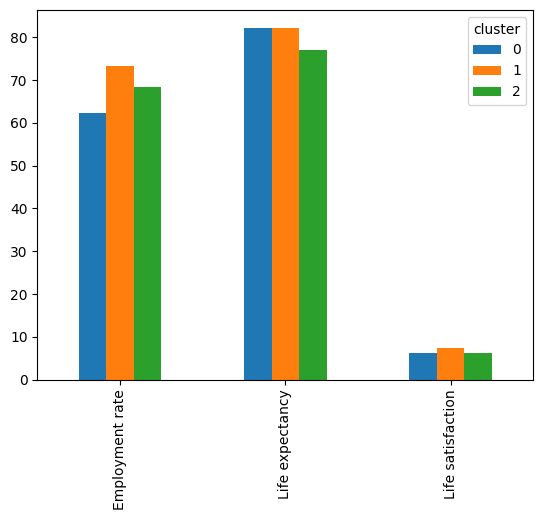

In [ ]:
cluster_means[['Employment rate',
               'Life expectancy',
               'Life satisfaction']].T.plot(kind='bar')

import matplotlib.pyplot as plt
plt.show()

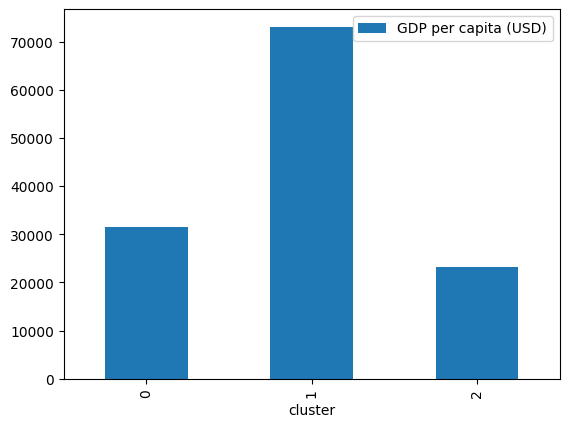

In [ ]:
cluster_means[['GDP per capita (USD)']].plot(kind='bar')

import matplotlib.pyplot as plt
plt.show()

Представим полученные результаты в графическом виде:

Графики подтверждают, что выделенные кластеры различаются по уровню развития: кластер 1 — наиболее развитые страны, кластер 0 — средний уровень, кластер 2 — более низкий уровень (при это главный фактор, по которому видны различия - это уровень ВВП)


***Пункты f-g*** -регрессия внутри кластеров

Проведем более детальный анализ и внутри каждого кластера построим свою регрессионную модель.

Зависимая переменная в нашем случае - удовлетворённость жизнью (Life satisfaction). Эта переменная отражает общий уровень благополучия.

В качестве независимых переменных берем:

-ВВП на душу населения,

-уровень занятости,

-продолжительность жизни.

Регрессия строится отдельно для каждого кластера, так как хотим сравнить влияние факторов в разных группах стран.

In [ ]:
import statsmodels.api as sm

for c in [0, 1, 2]:
    print('Кластер', c)

    subset = data[data['cluster'] == c]

    Y = subset['Life satisfaction']
    X = subset[['GDP per capita (USD)',
                'Employment rate',
                'Life expectancy']]

    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    print(model.summary())
    print('\n\n')

Кластер 0
                            OLS Regression Results                            
Dep. Variable:      Life satisfaction   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     2.956
Date:                Tue, 31 Mar 2026   Prob (F-statistic):             0.0979
Time:                        12:41:28   Log-Likelihood:                -4.3307
No. Observations:                  12   AIC:                             16.66
Df Residuals:                       8   BIC:                             18.60
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

По полученным значениям сделаем выводы:

***Кластер 0***
Качество модели среднее: R квадрат равен 0.53, то есть примерно половина изменений объясняется выбранными факторами.
ВВП оказывает наибольшее влияние, так как у ВВП самый заметный коэффициент и более низкое p-value по сравнению с другими переменными. Это означает, что при росте дохода удовлетворённость жизнью немного увеличивается.

При этом занятость и продолжительность жизни почти не влияют, так как их p-value высокие.

**Кластер 1**
Модель слабая: квадрат R равен 0.20.

Все факторы имеют высокие p-value => они не объясняют различия в удовлетворённости жизнью.
Это можно объяснить тем, что в этих странах уже высокий уровень развития, и различия в уровне жизни зависят не от базовых факторов (дохода и т.д.), а от других причин.

***Кластер 2***
Самая сильная из моделей: квадрат R равен 0.81, то есть факторы хорошо объясняют различия.

ВВП снова оказывает наибольшее влияние. Это видно по коэффициенту: он больше, чем у других переменных, и показывает, что при росте дохода удовлетворённость жизнью увеличивается.
Однако из-за малого количества стран p-value остаются выше 0.05, поэтому результаты нужно интерпретировать "аккуратно".
